In [1]:
import os
from pathlib import Path
%matplotlib inline
import seaborn as sns

In [2]:
from datetime import datetime
from glob import glob

import lightning as pl
import numpy as np
import pandas as pd
import wandb
from gait_ml.data.datamodule import GaitDataModule
from gait_ml.model.litmodel import LitSeq2Seq
from lightning.pytorch.callbacks import LearningRateMonitor, ModelCheckpoint
from lightning.pytorch.loggers import WandbLogger
from sklearn.model_selection import StratifiedKFold, train_test_split
from hydra import initialize, compose
import hydra
from omegaconf import DictConfig
import torch

from gait_ml import evaluate

from torchmetrics.classification import (
    MulticlassPrecision,
    MulticlassRecall,
    BinaryPrecision,
    BinaryRecall,
    Accuracy,
    ConfusionMatrix,
    MulticlassConfusionMatrix,
    MulticlassF1Score,
    F1Score
)
import matplotlib.pyplot as plt


def calculate_gait_mae(ground_truth: np.ndarray, prediction: np.ndarray, tolerance: int = 20):
    """
    Matches gait events and computes overall and per-class MAE in one pass.

    Args:
        ground_truth: Array of ground truth labels.
        prediction: Array of predicted labels.
        tolerance: Max distance to consider a match.

    Returns:
        A tuple containing:
        - overall_mae (float): The MAE across all matched events.
        - per_class_mae (dict): A dictionary mapping class labels to their MAE.
    """
    gt_indices = np.where(ground_truth > 0)[0]
    available_preds = list(np.where(prediction > 0)[0])
    
    # Store tuples of (label, absolute_error) for each successful match
    errors_by_class = []
    
    # Greedily match each ground truth event to the closest prediction
    for gt_idx in gt_indices:
        gt_label = ground_truth[gt_idx]
        best_dist = float('inf')
        best_match_idx = -1
        
        # Find the closest available prediction of the same class within tolerance
        for pred_idx in available_preds:
            if prediction[pred_idx] == gt_label:
                dist = abs(gt_idx - pred_idx)
                if dist <= tolerance and dist < best_dist:
                    best_dist = dist
                    best_match_idx = pred_idx
        
        # If a match is found, record its error and remove it from the pool
        if best_match_idx != -1:
            error = abs(gt_idx - best_match_idx)
            errors_by_class.append((gt_label, error))
            available_preds.remove(best_match_idx)
            
    if not errors_by_class:
        return np.nan, {}

    # --- Calculate Final Metrics ---
    
    # Overall MAE is the mean of all collected errors
    all_errors = [err for lbl, err in errors_by_class]
    overall_mae = np.mean(all_errors)
    
    # Per-class MAE is calculated by grouping errors by label
    unique_labels = sorted(np.unique([lbl for lbl, err in errors_by_class]))
    per_class_mae = {
        int(label): np.mean([err for lbl, err in errors_by_class if lbl == label])
        for label in unique_labels
    }
    
    return overall_mae, per_class_mae



# @hydra.main(config_path="../configs", config_name="train_config", version_base="1.3")
def eval(data_set: str, model_fpath: str, fold: int):
    with initialize(config_path="../configs", job_name="train", version_base="1.3"):
        config = compose(config_name="train_config")
    pl.seed_everything(config.general.random_state)
    all_files = glob(config.general.data_path, recursive=True)
    all_files = np.sort(all_files)
    print(f"Processing: {len(all_files)} samples")

    ids = [int(i.split("/")[-1].split("_")[0]) for i in all_files]
    group_df = pd.read_csv(config.general.group_file, index_col="ID")
    group_df.columns = ["group", "status"]
    group_df = group_df[group_df.group.notna()]
    group_df.replace("h", 0, inplace=True)
    group_df.replace("p", 1, inplace=True)
    grouping = group_df.loc[ids].group.values

    skf = StratifiedKFold(
        n_splits=config.general.n_splits,
        shuffle=True,
        random_state=config.general.random_state,
    )

    # Outer loop for K-Fold cross-validation
    # This loop creates the primary TEST set for each fold.
    for cur_fold, (train_val_index, test_index) in enumerate(
        skf.split(np.arange(len(ids)).reshape(-1, 1), grouping)
    ):
        
        if cur_fold != fold:
            continue
        print("cur_fold", cur_fold)
        print("input fold", fold)
        print(
            f"=============== FOLD {cur_fold + 1}/{config.general.n_splits} ================"
        )
        print("current_test set:", test_index)
        # Split data into a temporary training+validation set and the final test set
        X_train_val, X_test = (
            np.arange(len(ids))[train_val_index],
            np.arange(len(ids))[test_index],
        )
        print(f"X_train_val:", X_train_val)
        print(f"train_val_index:", train_val_index)
        print(f"X_test:", X_test)
        print(f"test_index:", test_index)
        
        y_train_val, y_test = grouping[train_val_index], grouping[test_index]

        X_train, X_val, y_train, y_val = train_test_split(
            X_train_val,
            y_train_val,
            test_size=0.25,
            stratify=y_train_val,
            random_state=1,
        )

        model = LitSeq2Seq(
            input_dim=config.model.input_dim,
            output_dim=config.model.output_dim,
            hidden_dim=config.model.hidden_dim,
            num_layers=config.model.num_layers,
            dropout_prob=config.model.dropout_prob,
            learning_rate=config.model.learning_rate,
            teacher_forcing_ratio=config.model.teacher_forcing_ratio,
        )

        current_time = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
        run_name = f"GRU-expandlabel{config.data.expand_labels}_{current_time}"
        # wandb_logger = WandbLogger(
        #     project=config.general.project_name,
        #     name=run_name,
        #     log_model="all",
        # )
        checkpoint_callback = ModelCheckpoint(
            monitor=config.training.monitor_metric,
            mode=config.training.monitor_mode,
            save_top_k=config.training.save_top_k,
            dirpath=f"{config.general.project_name}/{run_name}/checkpoints/",
            filename="model-{epoch:02d}-{val_f1score:.2f}",
        )
        # lr_monitor = LearningRateMonitor(logging_interval="step")

        # trainer = pl.Trainer(
        #     max_epochs=config.training.num_epochs,
        #     accelerator=config.training.accelerator,
        #     devices=config.training.devices,
        #     log_every_n_steps=config.training.log_every_n_steps,
        #     check_val_every_n_epoch=config.training.check_val_every_n_epoch,
        #     enable_progress_bar=True,
        #     logger=wandb_logger,
        #     callbacks=[checkpoint_callback, lr_monitor],
        # )
            
        checkpoint_callback.best_model_path = model_fpath
        print(f"Best model: {checkpoint_callback.best_model_path}")
        device_ = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
        best_model = LitSeq2Seq.load_from_checkpoint(checkpoint_callback.best_model_path).to(device_)

        testset_f1_scores = []
        testset_pc_f1_scores = []
        testset_pc_precision = []
        testset_pc_recall = []
        testset_mae = []
        testset_pc_mae = []
        testset_cm = []
        
        if data_set == "test":
            cur_set_to_test = X_test
        else:
            cur_set_to_test = X_val

        print("X_test:", X_test)
        print("X_val:", X_val)

        group_assigment = []
        for curr_test_idx in cur_set_to_test.tolist():
            print(f" === Currently Evaluating curr_test_idx: {curr_test_idx} === ")
            test_datamodule = GaitDataModule(all_files,
                                             batch_size=1024,
                                             window_size=config.data.window_size,
                                             step_size=config.data.step_size,
                                             train_idx=X_train.squeeze(), 
                                             val_idx=X_val.squeeze(),
                                             test_idx=[curr_test_idx],
                                             expand_labels=config.data.expand_labels,
                                             acc_sheet_name="Linear Accelerometer",
                                             num_workers=16,
                                            )
            test_datamodule.setup(data_set)
            if data_set == "test":
                test_dataloader = test_datamodule.test_dataloader()
            elif data_set == "val": 
                test_dataloader = test_datamodule.val_dataloader()
            else:
                raise ValueError(f"Not supported -> {data_set}")
            best_model.eval()
            with torch.no_grad():
                pred=[]
                target=[]
                for sample_input, sample_target in test_dataloader:
                    sample_input = sample_input.to(device_)
                    sample_target = sample_target.to(device_)
                    print(sample_input.shape)
                    predicted_output = best_model(sample_input, sample_target, teacher_forcing_ratio=0.0)
                    pred.append(predicted_output)
                    target.append(sample_target)
                
                cur_pred = torch.concat(pred).reshape(-1, 3)
                cur_pred = torch.nn.functional.softmax(cur_pred, dim=-1).argmax(1)
                cur_target = torch.concat(target).reshape(-1)
                reshaped_input = sample_input.reshape(-1, sample_input.shape[-1]).cpu().numpy()
                
                print("Pred", cur_pred.shape, "Target", cur_target.shape)
                # cm = MulticlassConfusionMatrix(num_classes=3, normalize="true").to(device_)
                # cm.update(cur_pred, cur_target)
                # fig_, ax_ = cm.plot()
                # plt.show()
                
                ALIGN_TOLERANCE = 3
                merged_preds = evaluate.merge_clustered_events(cur_pred.cpu().numpy())
                merged_targets = evaluate.merge_clustered_events(cur_target.cpu().numpy())
                aligned_preds = evaluate.align_events(merged_targets, merged_preds, ALIGN_TOLERANCE)
                
                
                cm = MulticlassConfusionMatrix(num_classes=3, normalize="true")
                cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                fig_, ax_ = cm.plot()
                plt.show()
                unnormalized_cm = MulticlassConfusionMatrix(num_classes=3, normalize=None)
                unnormalized_cm.update(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                ucm_tensor = unnormalized_cm.compute()
                testset_cm.append(ucm_tensor)
                print(ucm_tensor)
                
                num_classes = 3
                f1_macro = MulticlassF1Score(num_classes=num_classes, average='macro')
                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                print(f"Macro F1-Score: {f1_macro_score.item():.4f} ✨")

                pc_f1score = MulticlassF1Score(num_classes=num_classes, average='none')
                perclass_f1scores = pc_f1score(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_f1_scores.append(perclass_f1scores)
                print(f"perclass_f1scores:", perclass_f1scores)

                pc_precision = MulticlassPrecision(num_classes=num_classes, average='none')
                perclass_precision = pc_precision(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_precision.append(perclass_precision)
                print(f"perclass_precision:", perclass_precision)

                pc_recall = MulticlassRecall(num_classes=num_classes, average='none')
                perclass_recall = pc_recall(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                testset_pc_recall.append(perclass_recall)
                print(f"perclass_recall:", perclass_recall)

                f1_macro_score = f1_macro(torch.tensor(aligned_preds), torch.tensor(merged_targets))
                
                overall, per_class = calculate_gait_mae(merged_targets, merged_preds)
                overall = overall.item() if not np.isnan(overall) else np.nan
                print(f"MAE overall: {overall:.4f} ✨")
                print(f"MAE per_class: {per_class} ✨")
                testset_f1_scores.append(f1_macro_score)
                testset_mae.append(overall)
                testset_pc_mae.append(per_class)
                group_assigment.append(grouping[curr_test_idx])
            # break
        # break
    return {
            "testset_f1_scores": torch.tensor(testset_f1_scores).numpy(),
            "testset_pc_f1_scores": torch.stack(testset_pc_f1_scores).numpy(),
            "testset_pc_precision": torch.stack(testset_pc_precision).numpy(),
            "testset_pc_recall": torch.stack(testset_pc_recall).numpy(),
            "testset_mae": np.stack(testset_mae),
            "testset_pc_mae": testset_pc_mae,
            "testset_cm": torch.stack(testset_cm).numpy(),
            "group": np.stack(group_assigment),
           }


# 1. Evaluate Validation set

In [517]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [0, 1, 2, 4, 8]
data_set = "val"
for i in range(num_folds):
    for j in exp_labels:
        curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        save_name = f"Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        if data_set == "test" or data_set == "val":
            save_name = f"{data_set}set_{save_name}"
        if not os.path.exists(save_name):
            print(f"=== Running model: {save_name} ===")
            testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i)
            np.savez(save_name, **testset_results)

# 2. Plot 

## 2.1 Plot F1-score and MAE box plot validation set

 === Processing valset_Fold1_explabel0_model-epoch=109-val_f1score=0.37.npz === 
 === Processing valset_Fold1_explabel1_model-epoch=56-val_f1score=0.76.npz === 
 === Processing valset_Fold1_explabel2_model-epoch=52-val_f1score=0.85.npz === 
 === Processing valset_Fold1_explabel4_model-epoch=52-val_f1score=0.91.npz === 
 === Processing valset_Fold1_explabel8_model-epoch=25-val_f1score=0.94.npz === 
 === Processing valset_Fold2_explabel0_model-epoch=92-val_f1score=0.40.npz === 
 === Processing valset_Fold2_explabel1_model-epoch=53-val_f1score=0.78.npz === 
 === Processing valset_Fold2_explabel2_model-epoch=35-val_f1score=0.86.npz === 
 === Processing valset_Fold2_explabel4_model-epoch=31-val_f1score=0.92.npz === 
 === Processing valset_Fold2_explabel8_model-epoch=48-val_f1score=0.95.npz === 
 === Processing valset_Fold3_explabel0_model-epoch=12-val_f1score=0.33.npz === 
 === Processing valset_Fold3_explabel1_model-epoch=78-val_f1score=0.75.npz === 
 === Processing valset_Fold3_explabel2_

/tmp/ipykernel_884594/1194054581.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels([u"\u00B1 10 [ms]", u"\u00B1 20 [ms]", u"\u00B1 40 [ms]", u"\u00B1 80 [ms]"])


[Text(0, 0, '± 10 [ms]'),
 Text(1, 0, '± 20 [ms]'),
 Text(2, 0, '± 40 [ms]'),
 Text(3, 0, '± 80 [ms]')]

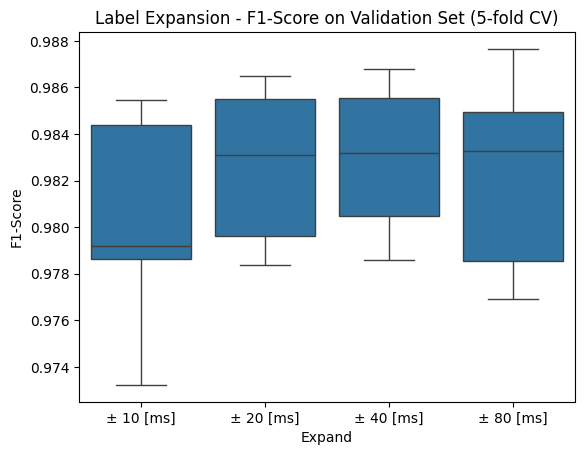

In [305]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [0, 1, 2, 4, 8]
all_results = []
for i in range(num_folds):
    for j in exp_labels:
        curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        fname = f"valset_Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        print(f" === Processing {fname} === ")
        curr_results = np.load(fname)
        curr_results = {**curr_results}
        curr_results["fold"] = i + 1
        curr_results["explabel"] = j
        all_results.append(curr_results)

all_results_df = pd.DataFrame(all_results)
print(all_results_df.head())

# Simplified Code for MEAN OF LIST LENGTHS
cur_feature_name = "testset_f1_scores"
cur_metric_name = "F1-Score"
f1_scores = all_results_df.groupby(["fold", "explabel"])[[cur_feature_name]].agg(lambda s: s.apply(np.nanmean))
f1_scores = f1_scores.reset_index()
f1_scores.head()

# f1_scores.groupby(["explabel"]).mean()
# f1_scores.groupby(["explabel"]).std()
plot_df = pd.melt(f1_scores[f1_scores.explabel!=0], id_vars=["fold", "explabel"])


plot_df = plot_df.rename(columns={"explabel": "Expand", "value": cur_metric_name})

g = sns.boxplot(data=plot_df, x="Expand", y=cur_metric_name)
plt.title("Label Expansion - F1-Score on Validation Set (5-fold CV)")
g.set_xticklabels([u"\u00B1 10 [ms]", u"\u00B1 20 [ms]", u"\u00B1 40 [ms]", u"\u00B1 80 [ms]"])

In [82]:
# all_results_df[all_results_df.explabel==1].testset_f1_scores.apply(lambda x: x.mean()).mean()

np.float32(0.982852)

In [306]:
import pandas as pd
import numpy as np
from scipy import stats

# --- Simplified Aggregation ---

# A single lambda function to calculate the 95% Confidence Interval bounds (CI)
# t.interval returns a tuple: (lower_bound, upper_bound)
def get_ci_bounds(series, confidence=0.95):
    """Calculates the 95% CI (lower, upper) for a Series."""
    if series.empty:
        return np.nan, np.nan
    # stats.sem calculates the Standard Error of the Mean (sigma / sqrt(n))
    sem = stats.sem(series, ddof=1)
    # stats.t.interval computes the confidence interval
    return stats.t.interval(confidence, len(series) - 1, loc=series.mean(), scale=sem)

# Assuming your DataFrame 'f1_scores' and column 'cur_feature_name' are defined.
decimals = 3

# 1. Aggregate the data (combining the CI calculation)
report_df = f1_scores.groupby('explabel')[cur_feature_name].agg(
    mean_val='mean',
    std_val='std',
    ci_bounds=get_ci_bounds, # Uses the single function to get a tuple of bounds
    count='size'
).reset_index()

# 2. Split the CI tuple into separate columns for easier formatting
report_df[['ci_lower', 'ci_upper']] = pd.DataFrame(
    report_df['ci_bounds'].tolist(),
    index=report_df.index
)
report_df = report_df.drop(columns=['ci_bounds'])


# --- Simplified Formatting (Using f-strings and round) ---

# 3. Create the formatted columns using vectorization (not row-wise apply) where possible
# Note: Using .round() before f-string formatting ensures correct precision.

# Mean +/- Std Column
report_df['Mean_Std'] = (
    report_df['mean_val'].round(decimals).astype(str) +
    ' $\\pm$ ' +
    report_df['std_val'].round(decimals).astype(str)
)

# Confidence Interval Column
report_df['95% CI'] = (
    '[' +
    report_df['ci_lower'].round(decimals).astype(str) +
    ', ' +
    report_df['ci_upper'].round(decimals).astype(str) +
    ']'
)


# 4. Select and rename final columns for publication
publication_table = report_df[['explabel', 'count', 'Mean_Std', '95% CI']]
publication_table.columns = ['Experiment Label (Group)', 'N', 'Mean $\\pm$ Std. Dev.', '95% Confidence Interval']

publication_table

,Experiment Label (Group),N,Mean $\pm$ Std. Dev.,95% Confidence Interval
0,0,5,0.495 $\pm$ 0.206,"[0.239, 0.751]"
1,1,5,0.98 $\pm$ 0.005,"[0.974, 0.986]"
2,2,5,0.983 $\pm$ 0.004,"[0.978, 0.987]"
3,4,5,0.983 $\pm$ 0.003,"[0.979, 0.987]"
4,8,5,0.982 $\pm$ 0.004,"[0.977, 0.988]"


In [307]:
# Reporting validation set metrics
publication_table.to_latex()

'\\begin{tabular}{lrrll}\n\\toprule\n & Experiment Label (Group) & N & Mean $\\pm$ Std. Dev. & 95% Confidence Interval \\\\\n\\midrule\n0 & 0 & 5 & 0.495 $\\pm$ 0.206 & [0.239, 0.751] \\\\\n1 & 1 & 5 & 0.98 $\\pm$ 0.005 & [0.974, 0.986] \\\\\n2 & 2 & 5 & 0.983 $\\pm$ 0.004 & [0.978, 0.987] \\\\\n3 & 4 & 5 & 0.983 $\\pm$ 0.003 & [0.979, 0.987] \\\\\n4 & 8 & 5 & 0.982 $\\pm$ 0.004 & [0.977, 0.988] \\\\\n\\bottomrule\n\\end{tabular}\n'

## 2.2 Test set - Plot confusion matrix with CI on the test set using best model only

Seed set to 42


=== Running model: testset_Fold1_explabel4_model-epoch=52-val_f1score=0.91.npz ===
Processing: 46 samples
cur_fold 0
input fold 0
=============== FOLD 1/5 ================
current_test set: [ 2  7 10 13 15 17 20 23 27 34]
X_train_val: [ 0  1  3  4  5  6  8  9 11 12 14 16 18 19 21 22 24 25 26 28 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
train_val_index: [ 0  1  3  4  5  6  8  9 11 12 14 16 18 19 21 22 24 25 26 28 29 30 31 32
 33 35 36 37 38 39 40 41 42 43 44 45]
X_test: [ 2  7 10 13 15 17 20 23 27 34]
test_index: [ 2  7 10 13 15 17 20 23 27 34]
Best model: /home/geromevivar/projects/gait_ml/backpain/Fold1-GRU-expandlabel4_2025-10-09_16-22-18/checkpoints/model-epoch=52-val_f1score=0.91.ckpt
X_test: [ 2  7 10 13 15 17 20 23 27 34]
X_val: [24  6 18 41 26 11 22 42 32]
 === Currently Evaluating curr_test_idx: 2 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_03_T1/03_1_2mW_IPhone.xls


/tmp/ipykernel_956315/3050489518.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


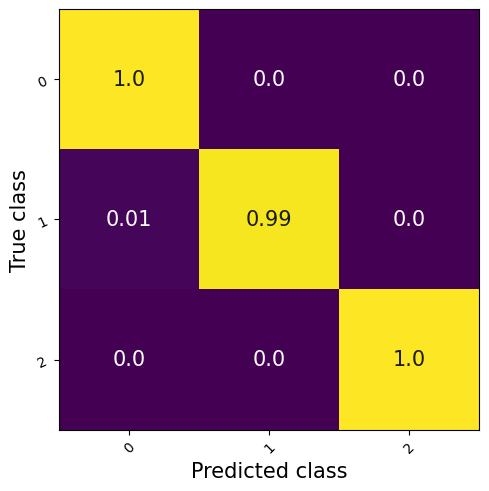

tensor([[12268,     5,     1],
        [    2,   133,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9901 ✨
perclass_f1scores: tensor([0.9997, 0.9744, 0.9963])
perclass_precision: tensor([0.9998, 0.9638, 0.9926])
perclass_recall: tensor([0.9995, 0.9852, 1.0000])
MAE overall: 1.5481 ✨
MAE per_class: {1: np.float64(1.651851851851852), 2: np.float64(1.4444444444444444)} ✨
 === Currently Evaluating curr_test_idx: 7 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_09_T1/09_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


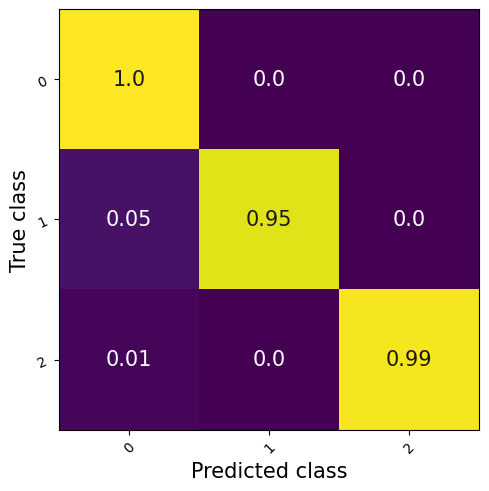

tensor([[12504,     7,     1],
        [    7,   137,     0],
        [    2,     0,   142]])
Macro F1-Score: 0.9801 ✨
perclass_f1scores: tensor([0.9993, 0.9514, 0.9895])
perclass_precision: tensor([0.9993, 0.9514, 0.9930])
perclass_recall: tensor([0.9994, 0.9514, 0.9861])
MAE overall: 1.5474 ✨
MAE per_class: {1: np.float64(1.6573426573426573), 2: np.float64(1.4366197183098592)} ✨
 === Currently Evaluating curr_test_idx: 10 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_12_T1/12_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


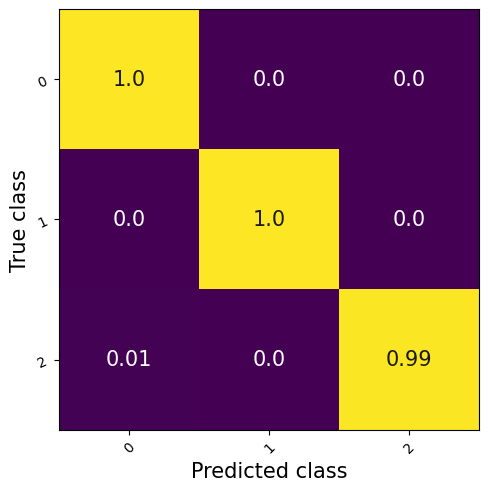

tensor([[12531,     0,     2],
        [    0,   134,     0],
        [    1,     0,   132]])
Macro F1-Score: 0.9962 ✨
perclass_f1scores: tensor([0.9999, 1.0000, 0.9888])
perclass_precision: tensor([0.9999, 1.0000, 0.9851])
perclass_recall: tensor([0.9998, 1.0000, 0.9925])
MAE overall: 1.0861 ✨
MAE per_class: {1: np.float64(0.9328358208955224), 2: np.float64(1.2406015037593985)} ✨
 === Currently Evaluating curr_test_idx: 13 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_15_T1/15_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


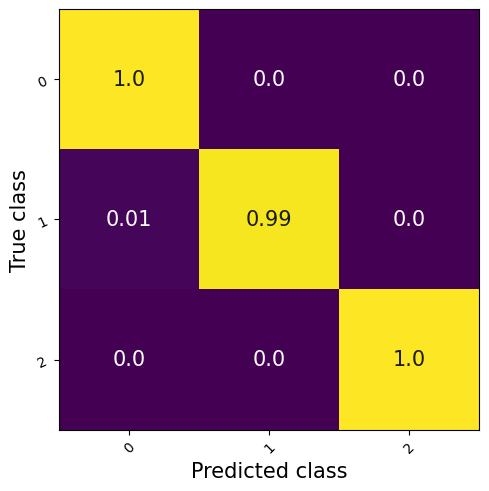

tensor([[12495,     3,     2],
        [    2,   148,     0],
        [    0,     0,   150]])
Macro F1-Score: 0.9922 ✨
perclass_f1scores: tensor([0.9997, 0.9834, 0.9934])
perclass_precision: tensor([0.9998, 0.9801, 0.9868])
perclass_recall: tensor([0.9996, 0.9867, 1.0000])
MAE overall: 0.9667 ✨
MAE per_class: {1: np.float64(0.7933333333333333), 2: np.float64(1.14)} ✨
 === Currently Evaluating curr_test_idx: 15 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_17_T1/17_1_2mW_IPhone.xls
cropped_array shape: (55, 256, 7)
all_arrays shape: (55, 256, 7)
torch.Size([55, 256, 6])
Pred torch.Size([14080]) Target torch.Size([14080])


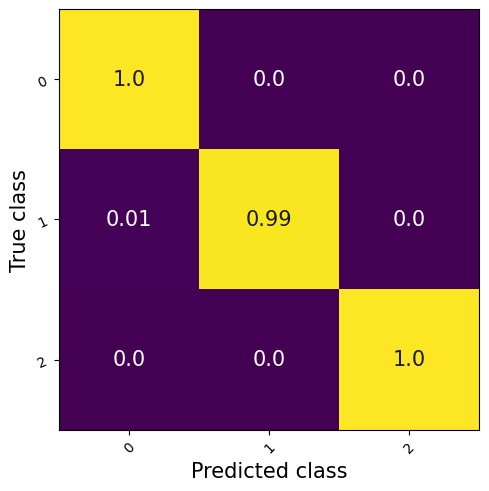

tensor([[13841,     0,     0],
        [    1,   119,     0],
        [    0,     0,   119]])
Macro F1-Score: 0.9986 ✨
perclass_f1scores: tensor([1.0000, 0.9958, 1.0000])
perclass_precision: tensor([0.9999, 1.0000, 1.0000])
perclass_recall: tensor([1.0000, 0.9917, 1.0000])
MAE overall: 1.2311 ✨
MAE per_class: {1: np.float64(0.9159663865546218), 2: np.float64(1.546218487394958)} ✨
 === Currently Evaluating curr_test_idx: 17 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_19_T1/19_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


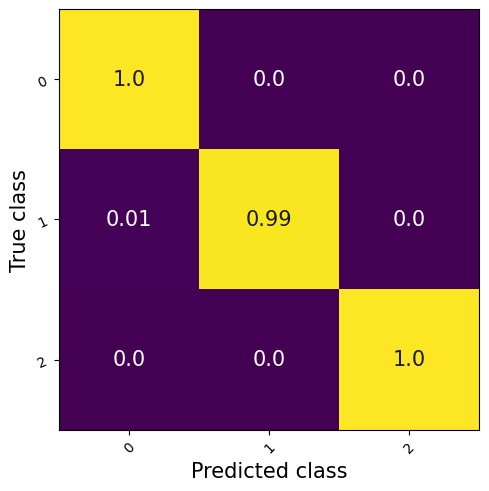

tensor([[12544,     4,     1],
        [    1,   125,     0],
        [    0,     0,   125]])
Macro F1-Score: 0.9921 ✨
perclass_f1scores: tensor([0.9998, 0.9804, 0.9960])
perclass_precision: tensor([0.9999, 0.9690, 0.9921])
perclass_recall: tensor([0.9996, 0.9921, 1.0000])
MAE overall: 0.6454 ✨
MAE per_class: {1: np.float64(0.8253968253968254), 2: np.float64(0.464)} ✨
 === Currently Evaluating curr_test_idx: 20 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_23_T1/23_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


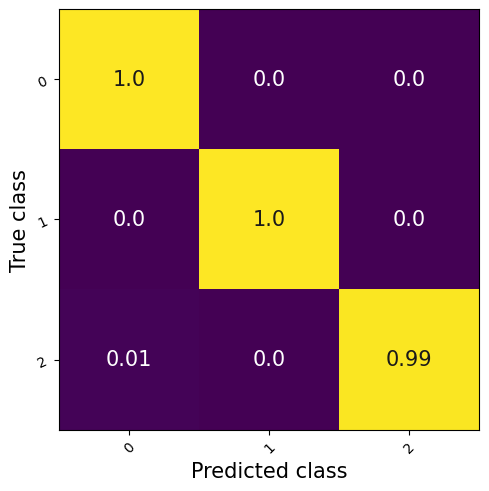

tensor([[12542,     0,     2],
        [    0,   128,     0],
        [    1,     0,   127]])
Macro F1-Score: 0.9961 ✨
perclass_f1scores: tensor([0.9999, 1.0000, 0.9883])
perclass_precision: tensor([0.9999, 1.0000, 0.9845])
perclass_recall: tensor([0.9998, 1.0000, 0.9922])
MAE overall: 1.5859 ✨
MAE per_class: {1: np.float64(0.9921875), 2: np.float64(2.1796875)} ✨
 === Currently Evaluating curr_test_idx: 23 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_26_T1/26_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


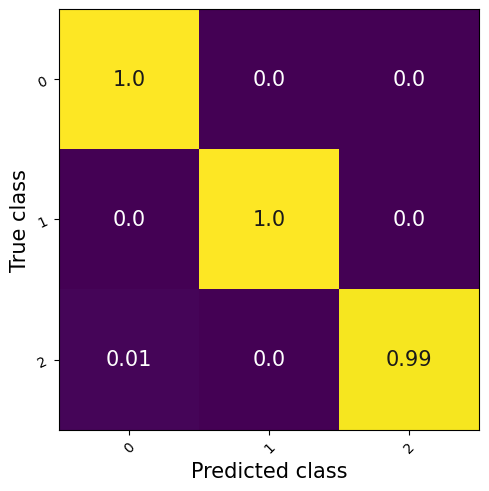

tensor([[12526,     0,     4],
        [    0,   135,     0],
        [    2,     0,   133]])
Macro F1-Score: 0.9926 ✨
perclass_f1scores: tensor([0.9998, 1.0000, 0.9779])
perclass_precision: tensor([0.9998, 1.0000, 0.9708])
perclass_recall: tensor([0.9997, 1.0000, 0.9852])
MAE overall: 1.3741 ✨
MAE per_class: {1: np.float64(1.0962962962962963), 2: np.float64(1.651851851851852)} ✨
 === Currently Evaluating curr_test_idx: 27 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_30_T1/30_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


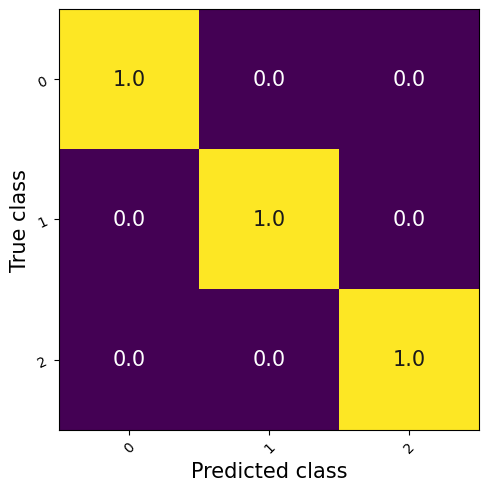

tensor([[12539,     2,     2],
        [    0,   129,     0],
        [    0,     0,   128]])
Macro F1-Score: 0.9948 ✨
perclass_f1scores: tensor([0.9998, 0.9923, 0.9922])
perclass_precision: tensor([1.0000, 0.9847, 0.9846])
perclass_recall: tensor([0.9997, 1.0000, 1.0000])
MAE overall: 1.0311 ✨
MAE per_class: {1: np.float64(1.0155038759689923), 2: np.float64(1.046875)} ✨
 === Currently Evaluating curr_test_idx: 34 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_37_T1/37_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


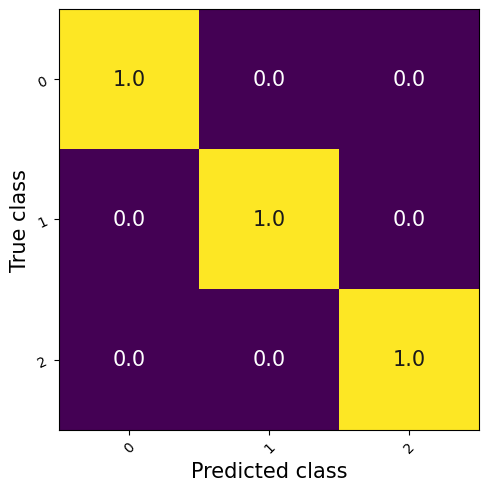

Seed set to 42


tensor([[12539,     1,     5],
        [    0,   128,     0],
        [    0,     0,   127]])
Macro F1-Score: 0.9922 ✨
perclass_f1scores: tensor([0.9998, 0.9961, 0.9807])
perclass_precision: tensor([1.0000, 0.9922, 0.9621])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 1.4588 ✨
MAE per_class: {1: np.float64(1.4296875), 2: np.float64(1.4881889763779528)} ✨
=== Running model: testset_Fold2_explabel4_model-epoch=31-val_f1score=0.92.npz ===
Processing: 46 samples
cur_fold 1
input fold 1
=============== FOLD 2/5 ================
current_test set: [ 0  5  9 16 19 25 28 32 40]
X_train_val: [ 1  2  3  4  6  7  8 10 11 12 13 14 15 17 18 20 21 22 23 24 26 27 29 30
 31 33 34 35 36 37 38 39 41 42 43 44 45]
train_val_index: [ 1  2  3  4  6  7  8 10 11 12 13 14 15 17 18 20 21 22 23 24 26 27 29 30
 31 33 34 35 36 37 38 39 41 42 43 44 45]
X_test: [ 0  5  9 16 19 25 28 32 40]
test_index: [ 0  5  9 16 19 25 28 32 40]
Best model: /home/geromevivar/projects/gait_ml/backpain/Fold2-GRU-expa

/tmp/ipykernel_956315/3050489518.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


cropped_array shape: (53, 256, 7)
all_arrays shape: (53, 256, 7)
torch.Size([53, 256, 6])
Pred torch.Size([13568]) Target torch.Size([13568])


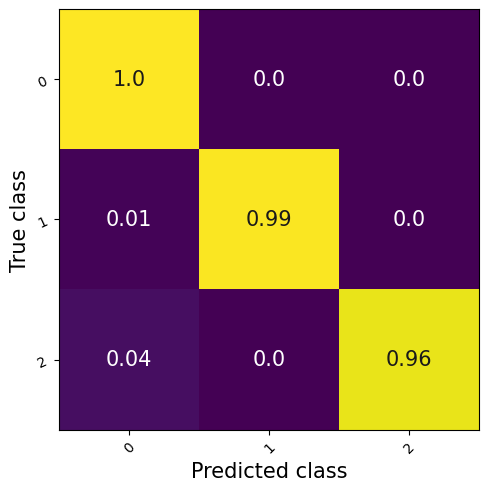

tensor([[13327,     7,     7],
        [    1,   113,     0],
        [    4,     0,   109]])
Macro F1-Score: 0.9724 ✨
perclass_f1scores: tensor([0.9993, 0.9658, 0.9520])
perclass_precision: tensor([0.9996, 0.9417, 0.9397])
perclass_recall: tensor([0.9990, 0.9912, 0.9646])
MAE overall: 1.1327 ✨
MAE per_class: {1: np.float64(0.5575221238938053), 2: np.float64(1.7079646017699115)} ✨
 === Currently Evaluating curr_test_idx: 5 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_07_T1/07_1_2mW_IPhone.xls
cropped_array shape: (48, 256, 7)
all_arrays shape: (48, 256, 7)
torch.Size([48, 256, 6])
Pred torch.Size([12288]) Target torch.Size([12288])


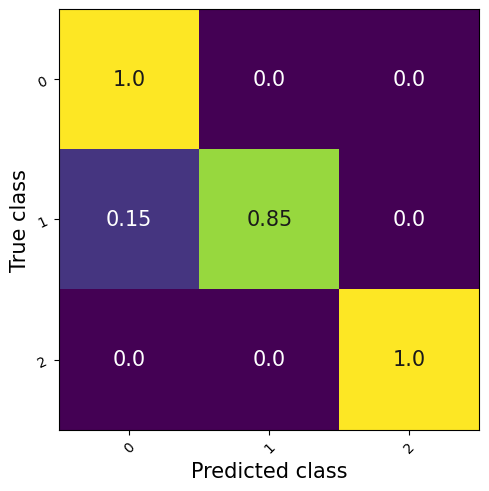

tensor([[11999,    25,     2],
        [   20,   111,     0],
        [    0,     0,   131]])
Macro F1-Score: 0.9406 ✨
perclass_f1scores: tensor([0.9980, 0.8315, 0.9924])
perclass_precision: tensor([0.9983, 0.8162, 0.9850])
perclass_recall: tensor([0.9978, 0.8473, 1.0000])
MAE overall: 1.3969 ✨
MAE per_class: {1: np.float64(2.0763358778625953), 2: np.float64(0.7175572519083969)} ✨
 === Currently Evaluating curr_test_idx: 9 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_11_T1/11_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


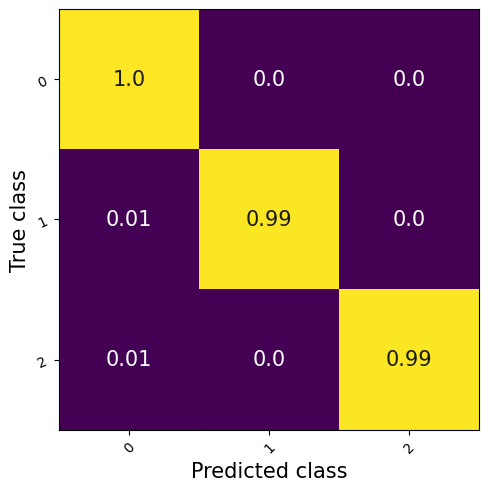

tensor([[12534,     2,     5],
        [    1,   129,     0],
        [    1,     0,   128]])
Macro F1-Score: 0.9884 ✨
perclass_f1scores: tensor([0.9996, 0.9885, 0.9771])
perclass_precision: tensor([0.9998, 0.9847, 0.9624])
perclass_recall: tensor([0.9994, 0.9923, 0.9922])
MAE overall: 0.9884 ✨
MAE per_class: {1: np.float64(0.6230769230769231), 2: np.float64(1.3565891472868217)} ✨
 === Currently Evaluating curr_test_idx: 16 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_18_T1/18_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


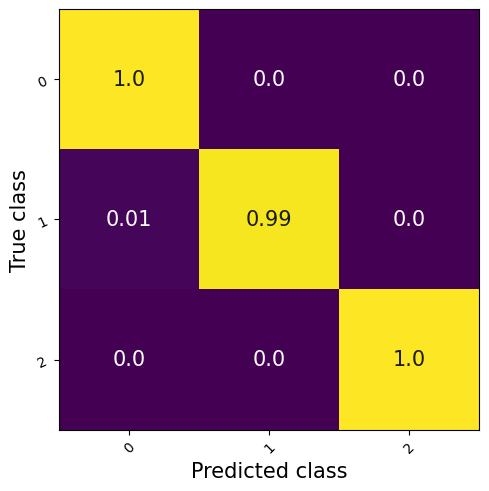

tensor([[12520,     5,     4],
        [    2,   134,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9865 ✨
perclass_f1scores: tensor([0.9996, 0.9745, 0.9854])
perclass_precision: tensor([0.9998, 0.9640, 0.9712])
perclass_recall: tensor([0.9993, 0.9853, 1.0000])
MAE overall: 0.8155 ✨
MAE per_class: {1: np.float64(0.9926470588235294), 2: np.float64(0.6370370370370371)} ✨
 === Currently Evaluating curr_test_idx: 19 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_21_T1/21_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


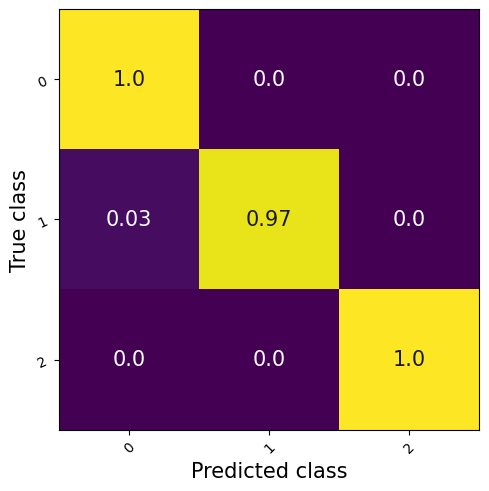

tensor([[12541,     6,     2],
        [    4,   122,     0],
        [    0,     0,   125]])
Macro F1-Score: 0.9841 ✨
perclass_f1scores: tensor([0.9995, 0.9606, 0.9921])
perclass_precision: tensor([0.9997, 0.9531, 0.9843])
perclass_recall: tensor([0.9994, 0.9683, 1.0000])
MAE overall: 1.1753 ✨
MAE per_class: {1: np.float64(1.5238095238095237), 2: np.float64(0.824)} ✨
 === Currently Evaluating curr_test_idx: 25 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_28_T1/28_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


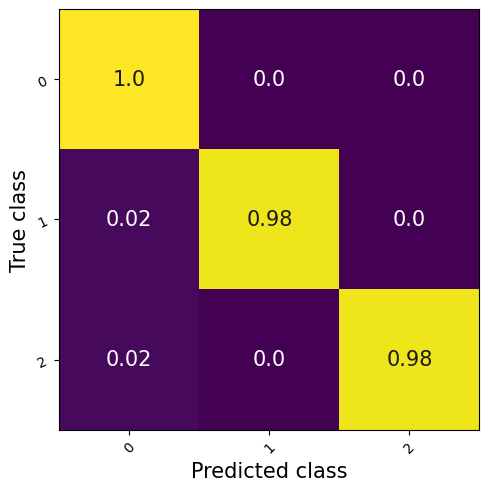

tensor([[12548,     4,     4],
        [    3,   119,     0],
        [    3,     0,   119]])
Macro F1-Score: 0.9808 ✨
perclass_f1scores: tensor([0.9994, 0.9714, 0.9714])
perclass_precision: tensor([0.9995, 0.9675, 0.9675])
perclass_recall: tensor([0.9994, 0.9754, 0.9754])
MAE overall: 1.3730 ✨
MAE per_class: {1: np.float64(1.2295081967213115), 2: np.float64(1.5163934426229508)} ✨
 === Currently Evaluating curr_test_idx: 28 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_31_T1/31_1_2mW_IPhone.xls
Skipping: 12782:12869 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


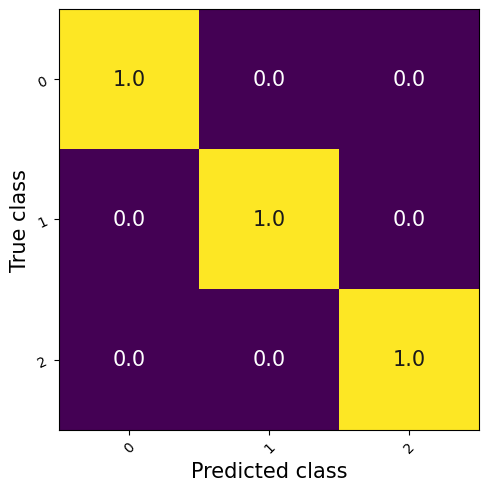

tensor([[12266,     0,     3],
        [    0,   138,     0],
        [    0,     0,   137]])
Macro F1-Score: 0.9963 ✨
perclass_f1scores: tensor([0.9999, 1.0000, 0.9892])
perclass_precision: tensor([1.0000, 1.0000, 0.9786])
perclass_recall: tensor([0.9998, 1.0000, 1.0000])
MAE overall: 1.0618 ✨
MAE per_class: {1: np.float64(1.3115942028985508), 2: np.float64(0.8102189781021898)} ✨
 === Currently Evaluating curr_test_idx: 32 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_35_T1/35_1_2mW_IPhone.xls
Skipping: 12877:12964 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


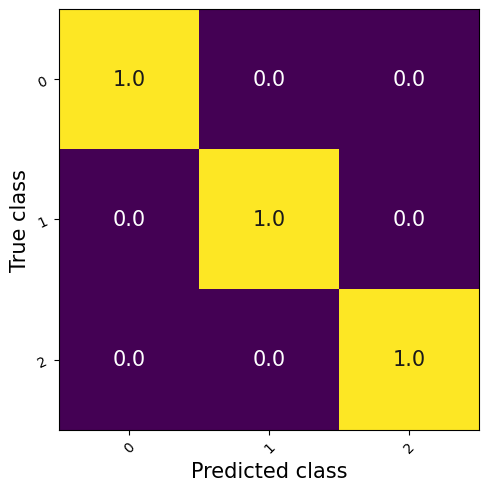

tensor([[12508,     2,     2],
        [    0,   144,     0],
        [    0,     0,   144]])
Macro F1-Score: 0.9953 ✨
perclass_f1scores: tensor([0.9998, 0.9931, 0.9931])
perclass_precision: tensor([1.0000, 0.9863, 0.9863])
perclass_recall: tensor([0.9997, 1.0000, 1.0000])
MAE overall: 0.5486 ✨
MAE per_class: {1: np.float64(0.4791666666666667), 2: np.float64(0.6180555555555556)} ✨
 === Currently Evaluating curr_test_idx: 40 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_43_T1/43_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
torch.Size([52, 256, 6])
Pred torch.Size([13312]) Target torch.Size([13312])


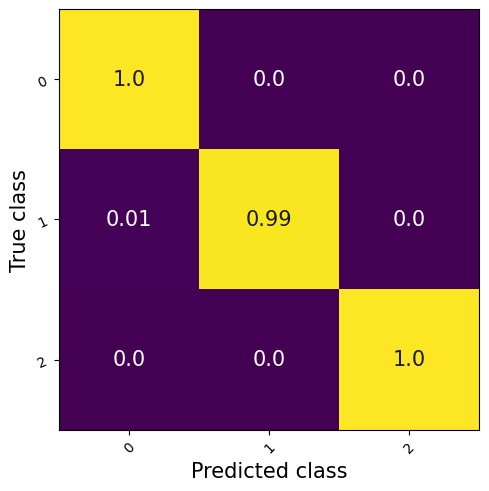

Seed set to 42


tensor([[13062,     3,     4],
        [    1,   121,     0],
        [    0,     0,   121]])
Macro F1-Score: 0.9891 ✨
perclass_f1scores: tensor([0.9997, 0.9837, 0.9837])
perclass_precision: tensor([0.9999, 0.9758, 0.9680])
perclass_recall: tensor([0.9995, 0.9918, 1.0000])
MAE overall: 0.6584 ✨
MAE per_class: {1: np.float64(0.7377049180327869), 2: np.float64(0.5785123966942148)} ✨
=== Running model: testset_Fold3_explabel4_model-epoch=27-val_f1score=0.91.npz ===
Processing: 46 samples
cur_fold 2
input fold 2
=============== FOLD 3/5 ================
current_test set: [ 4  6 11 18 24 33 35 42 45]
X_train_val: [ 0  1  2  3  5  7  8  9 10 12 13 14 15 16 17 19 20 21 22 23 25 26 27 28
 29 30 31 32 34 36 37 38 39 40 41 43 44]
train_val_index: [ 0  1  2  3  5  7  8  9 10 12 13 14 15 16 17 19 20 21 22 23 25 26 27 28
 29 30 31 32 34 36 37 38 39 40 41 43 44]
X_test: [ 4  6 11 18 24 33 35 42 45]
test_index: [ 4  6 11 18 24 33 35 42 45]
Best model: /home/geromevivar/projects/gait_ml/backpain/Fold3

/tmp/ipykernel_956315/3050489518.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


Skipping: 12627:12723 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


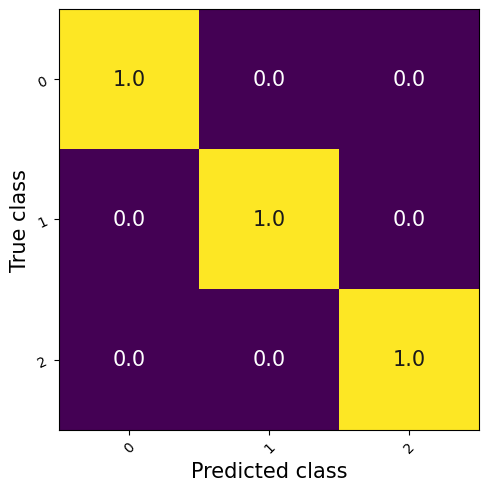

tensor([[12272,     4,     2],
        [    0,   133,     0],
        [    0,     0,   133]])
Macro F1-Score: 0.9925 ✨
perclass_f1scores: tensor([0.9998, 0.9852, 0.9925])
perclass_precision: tensor([1.0000, 0.9708, 0.9852])
perclass_recall: tensor([0.9995, 1.0000, 1.0000])
MAE overall: 0.6353 ✨
MAE per_class: {1: np.float64(0.6616541353383458), 2: np.float64(0.6090225563909775)} ✨
 === Currently Evaluating curr_test_idx: 6 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_08_T1/08_1_2mW_IPhone.xls
cropped_array shape: (48, 256, 7)
all_arrays shape: (48, 256, 7)
torch.Size([48, 256, 6])
Pred torch.Size([12288]) Target torch.Size([12288])


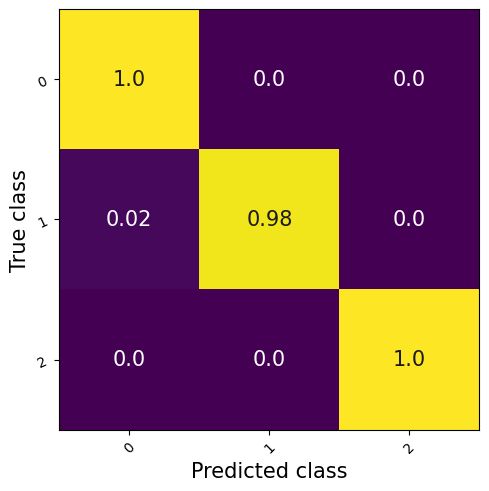

tensor([[12014,     4,     2],
        [    3,   131,     0],
        [    0,     0,   134]])
Macro F1-Score: 0.9887 ✨
perclass_f1scores: tensor([0.9996, 0.9740, 0.9926])
perclass_precision: tensor([0.9998, 0.9704, 0.9853])
perclass_recall: tensor([0.9995, 0.9776, 1.0000])
MAE overall: 0.9254 ✨
MAE per_class: {1: np.float64(1.2388059701492538), 2: np.float64(0.6119402985074627)} ✨
 === Currently Evaluating curr_test_idx: 11 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_13_T1/13_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


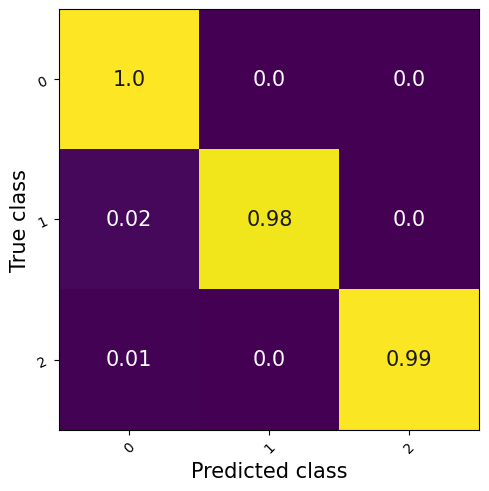

tensor([[12525,     4,     5],
        [    3,   130,     0],
        [    1,     0,   132]])
Macro F1-Score: 0.9837 ✨
perclass_f1scores: tensor([0.9995, 0.9738, 0.9778])
perclass_precision: tensor([0.9997, 0.9701, 0.9635])
perclass_recall: tensor([0.9993, 0.9774, 0.9925])
MAE overall: 0.8346 ✨
MAE per_class: {1: np.float64(0.8345864661654135), 2: np.float64(0.8345864661654135)} ✨
 === Currently Evaluating curr_test_idx: 18 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_20_T1/20_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
all_arrays shape: (51, 256, 7)
torch.Size([51, 256, 6])
Pred torch.Size([13056]) Target torch.Size([13056])


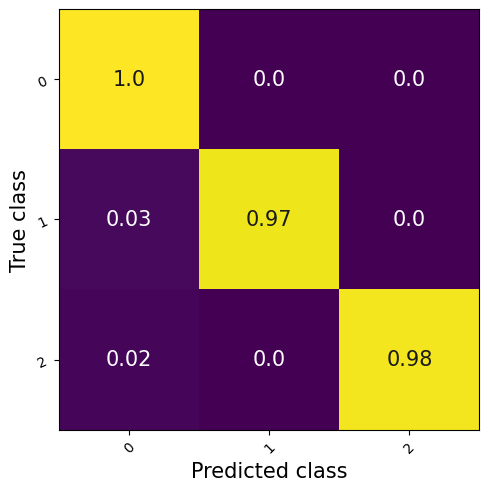

tensor([[12818,     1,     5],
        [    3,   113,     0],
        [    2,     0,   114]])
Macro F1-Score: 0.9841 ✨
perclass_f1scores: tensor([0.9996, 0.9826, 0.9702])
perclass_precision: tensor([0.9996, 0.9912, 0.9580])
perclass_recall: tensor([0.9995, 0.9741, 0.9828])
MAE overall: 1.2533 ✨
MAE per_class: {1: np.float64(0.911504424778761), 2: np.float64(1.5862068965517242)} ✨
 === Currently Evaluating curr_test_idx: 24 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_27_T1/27_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


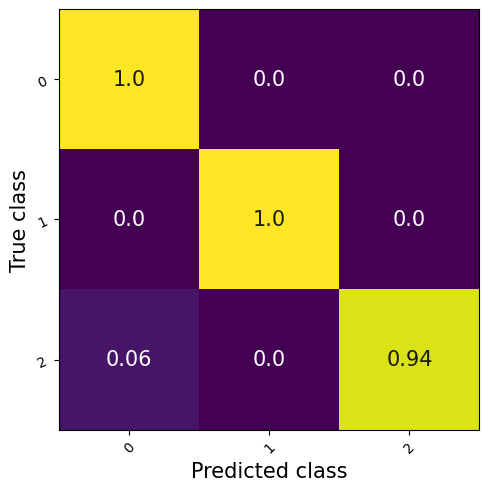

tensor([[12575,     4,     6],
        [    0,   108,     0],
        [    6,     0,   101]])
Macro F1-Score: 0.9750 ✨
perclass_f1scores: tensor([0.9994, 0.9818, 0.9439])
perclass_precision: tensor([0.9995, 0.9643, 0.9439])
perclass_recall: tensor([0.9992, 1.0000, 0.9439])
MAE overall: 1.4076 ✨
MAE per_class: {1: np.float64(1.4722222222222223), 2: np.float64(1.3398058252427185)} ✨
 === Currently Evaluating curr_test_idx: 33 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_36_T1/36_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


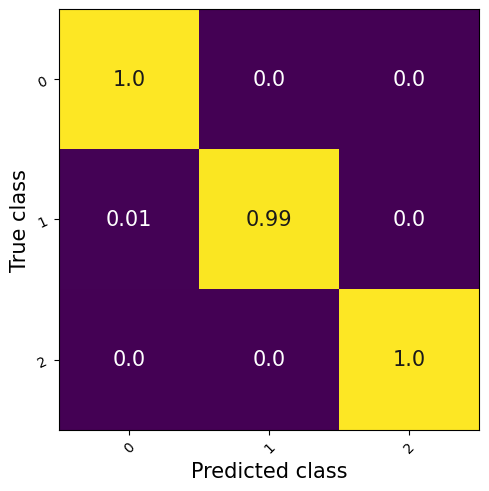

tensor([[12533,     4,     3],
        [    1,   129,     0],
        [    0,     0,   130]])
Macro F1-Score: 0.9898 ✨
perclass_f1scores: tensor([0.9997, 0.9810, 0.9886])
perclass_precision: tensor([0.9999, 0.9699, 0.9774])
perclass_recall: tensor([0.9994, 0.9923, 1.0000])
MAE overall: 1.0808 ✨
MAE per_class: {1: np.float64(0.8076923076923077), 2: np.float64(1.353846153846154)} ✨
 === Currently Evaluating curr_test_idx: 35 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_38_T1/38_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


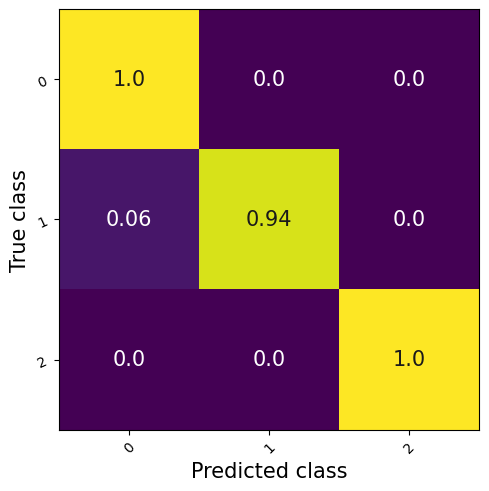

tensor([[12263,     8,     2],
        [    8,   128,     0],
        [    0,     0,   135]])
Macro F1-Score: 0.9777 ✨
perclass_f1scores: tensor([0.9993, 0.9412, 0.9926])
perclass_precision: tensor([0.9993, 0.9412, 0.9854])
perclass_recall: tensor([0.9992, 0.9412, 1.0000])
MAE overall: 0.9041 ✨
MAE per_class: {1: np.float64(1.0), 2: np.float64(0.8074074074074075)} ✨
 === Currently Evaluating curr_test_idx: 42 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_45_T1/45_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


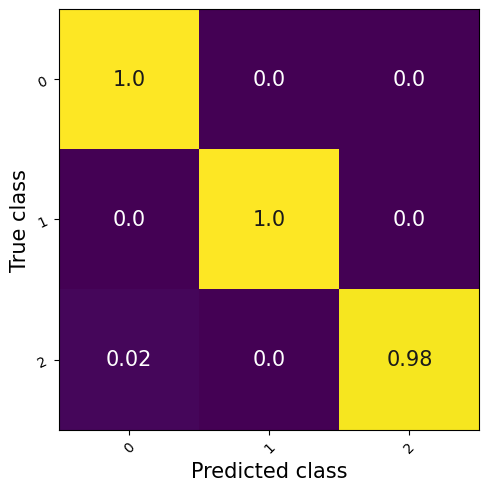

tensor([[12531,     5,     7],
        [    0,   129,     0],
        [    2,     0,   126]])
Macro F1-Score: 0.9820 ✨
perclass_f1scores: tensor([0.9994, 0.9810, 0.9655])
perclass_precision: tensor([0.9998, 0.9627, 0.9474])
perclass_recall: tensor([0.9990, 1.0000, 0.9844])
MAE overall: 0.6109 ✨
MAE per_class: {1: np.float64(0.6821705426356589), 2: np.float64(0.5390625)} ✨
 === Currently Evaluating curr_test_idx: 45 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_48_T1/48_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


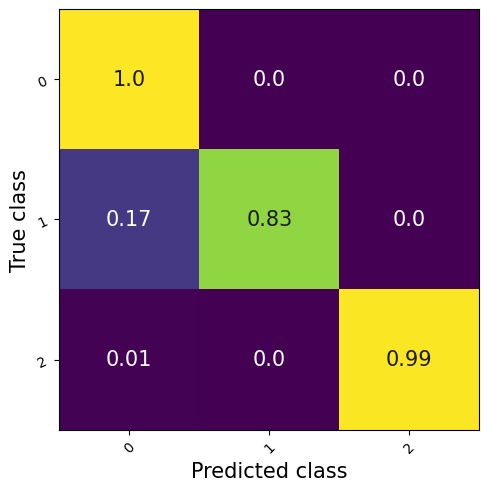

Seed set to 42


tensor([[12511,    23,     3],
        [   22,   110,     0],
        [    1,     0,   130]])
Macro F1-Score: 0.9377 ✨
perclass_f1scores: tensor([0.9980, 0.8302, 0.9848])
perclass_precision: tensor([0.9982, 0.8271, 0.9774])
perclass_recall: tensor([0.9979, 0.8333, 0.9924])
MAE overall: 1.8099 ✨
MAE per_class: {1: np.float64(2.257575757575758), 2: np.float64(1.3587786259541985)} ✨
=== Running model: testset_Fold4_explabel4_model-epoch=23-val_f1score=0.89.npz ===
Processing: 46 samples
cur_fold 3
input fold 3
=============== FOLD 4/5 ================
current_test set: [ 1 12 22 30 36 38 39 41 43]
X_train_val: [ 0  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 23 24 25 26
 27 28 29 31 32 33 34 35 37 40 42 44 45]
train_val_index: [ 0  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19 20 21 23 24 25 26
 27 28 29 31 32 33 34 35 37 40 42 44 45]
X_test: [ 1 12 22 30 36 38 39 41 43]
test_index: [ 1 12 22 30 36 38 39 41 43]
Best model: /home/geromevivar/projects/gait_ml/backpain/Fold4-

/tmp/ipykernel_956315/3050489518.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


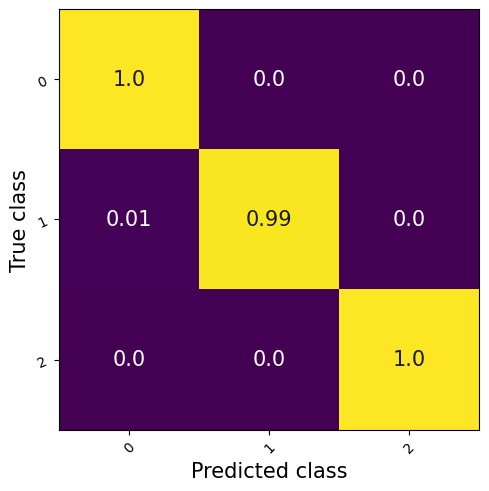

tensor([[12304,     3,     2],
        [    1,   117,     0],
        [    0,     0,   117]])
Macro F1-Score: 0.9915 ✨
perclass_f1scores: tensor([0.9998, 0.9832, 0.9915])
perclass_precision: tensor([0.9999, 0.9750, 0.9832])
perclass_recall: tensor([0.9996, 0.9915, 1.0000])
MAE overall: 0.6851 ✨
MAE per_class: {1: np.float64(0.8898305084745762), 2: np.float64(0.47863247863247865)} ✨
 === Currently Evaluating curr_test_idx: 12 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_14_T1/14_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


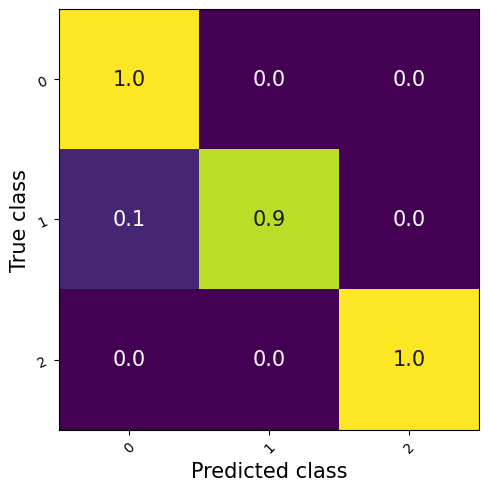

tensor([[12487,    16,     3],
        [   15,   132,     0],
        [    0,     0,   147]])
Macro F1-Score: 0.9612 ✨
perclass_f1scores: tensor([0.9986, 0.8949, 0.9899])
perclass_precision: tensor([0.9988, 0.8919, 0.9800])
perclass_recall: tensor([0.9985, 0.8980, 1.0000])
MAE overall: 1.3163 ✨
MAE per_class: {1: np.float64(2.0272108843537415), 2: np.float64(0.6054421768707483)} ✨
 === Currently Evaluating curr_test_idx: 22 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_25_T1/25_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
all_arrays shape: (51, 256, 7)
torch.Size([51, 256, 6])
Pred torch.Size([13056]) Target torch.Size([13056])


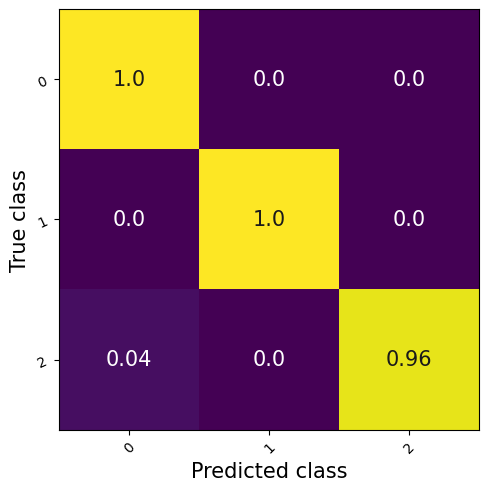

tensor([[12822,     2,     6],
        [    0,   113,     0],
        [    4,     0,   109]])
Macro F1-Score: 0.9823 ✨
perclass_f1scores: tensor([0.9995, 0.9912, 0.9561])
perclass_precision: tensor([0.9997, 0.9826, 0.9478])
perclass_recall: tensor([0.9994, 1.0000, 0.9646])
MAE overall: 1.2478 ✨
MAE per_class: {1: np.float64(1.4424778761061947), 2: np.float64(1.0530973451327434)} ✨
 === Currently Evaluating curr_test_idx: 30 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_33_T1/33_1_2mW_IPhone.xls
Skipping: 12808:12903 | index 0 is out of bounds for axis 0 with size 0
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


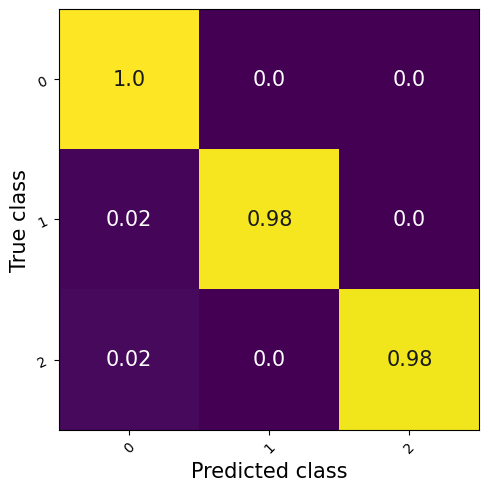

tensor([[12539,     3,     4],
        [    2,   125,     0],
        [    3,     0,   124]])
Macro F1-Score: 0.9842 ✨
perclass_f1scores: tensor([0.9995, 0.9804, 0.9725])
perclass_precision: tensor([0.9996, 0.9766, 0.9688])
perclass_recall: tensor([0.9994, 0.9843, 0.9764])
MAE overall: 0.8740 ✨
MAE per_class: {1: np.float64(1.1023622047244095), 2: np.float64(0.6456692913385826)} ✨
 === Currently Evaluating curr_test_idx: 36 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_39_T1/39_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


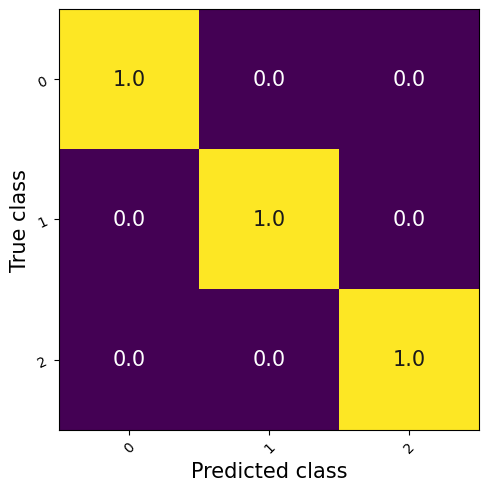

tensor([[12260,     2,     2],
        [    0,   140,     0],
        [    0,     0,   140]])
Macro F1-Score: 0.9952 ✨
perclass_f1scores: tensor([0.9998, 0.9929, 0.9929])
perclass_precision: tensor([1.0000, 0.9859, 0.9859])
perclass_recall: tensor([0.9997, 1.0000, 1.0000])
MAE overall: 1.0393 ✨
MAE per_class: {1: np.float64(0.8571428571428571), 2: np.float64(1.2214285714285715)} ✨
 === Currently Evaluating curr_test_idx: 38 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_41_T1/41_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


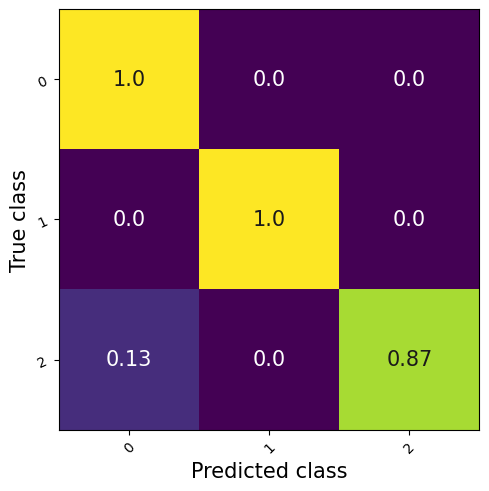

tensor([[12283,     0,    18],
        [    0,   122,     0],
        [   16,     0,   105]])
Macro F1-Score: 0.9531 ✨
perclass_f1scores: tensor([0.9986, 1.0000, 0.8607])
perclass_precision: tensor([0.9987, 1.0000, 0.8537])
perclass_recall: tensor([0.9985, 1.0000, 0.8678])
MAE overall: 1.2263 ✨
MAE per_class: {1: np.float64(1.0655737704918034), 2: np.float64(1.3884297520661157)} ✨
 === Currently Evaluating curr_test_idx: 39 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_42_T1/42_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
all_arrays shape: (51, 256, 7)
torch.Size([51, 256, 6])
Pred torch.Size([13056]) Target torch.Size([13056])


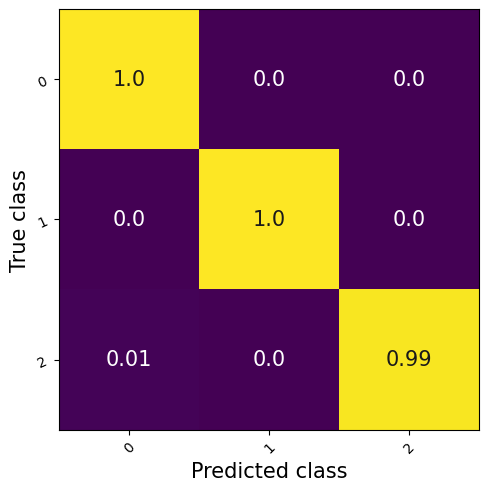

tensor([[12804,     1,     6],
        [    0,   123,     0],
        [    1,     0,   121]])
Macro F1-Score: 0.9892 ✨
perclass_f1scores: tensor([0.9997, 0.9960, 0.9719])
perclass_precision: tensor([0.9999, 0.9919, 0.9528])
perclass_recall: tensor([0.9995, 1.0000, 0.9918])
MAE overall: 0.9061 ✨
MAE per_class: {1: np.float64(0.9349593495934959), 2: np.float64(0.8770491803278688)} ✨
 === Currently Evaluating curr_test_idx: 41 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_44_T1/44_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


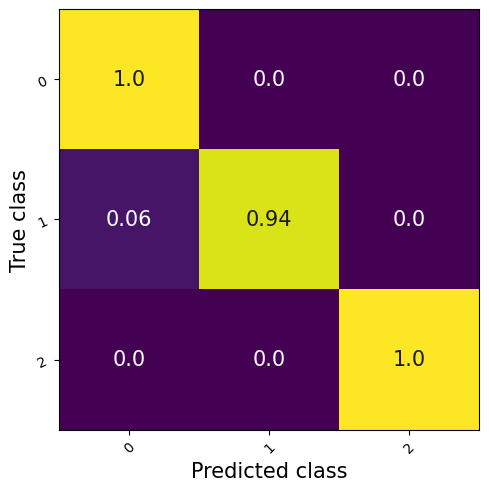

tensor([[12282,     9,     1],
        [    7,   119,     0],
        [    0,     0,   126]])
Macro F1-Score: 0.9775 ✨
perclass_f1scores: tensor([0.9993, 0.9370, 0.9960])
perclass_precision: tensor([0.9994, 0.9297, 0.9921])
perclass_recall: tensor([0.9992, 0.9444, 1.0000])
MAE overall: 0.8056 ✨
MAE per_class: {1: np.float64(1.1031746031746033), 2: np.float64(0.5079365079365079)} ✨
 === Currently Evaluating curr_test_idx: 43 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_46_T1/46_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


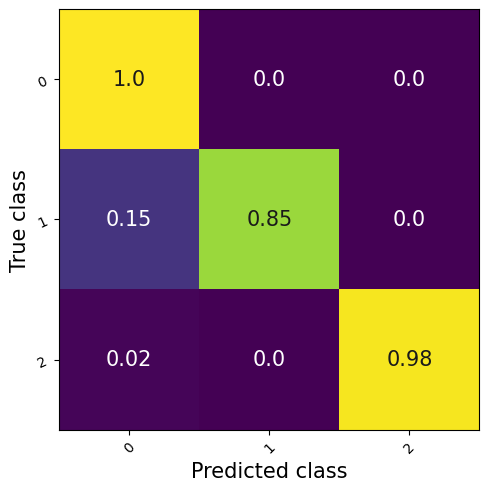

Seed set to 42


tensor([[12512,    21,     4],
        [   20,   112,     0],
        [    2,     0,   129]])
Macro F1-Score: 0.9402 ✨
perclass_f1scores: tensor([0.9981, 0.8453, 0.9773])
perclass_precision: tensor([0.9982, 0.8421, 0.9699])
perclass_recall: tensor([0.9980, 0.8485, 0.9847])
MAE overall: 1.3498 ✨
MAE per_class: {1: np.float64(1.7803030303030303), 2: np.float64(0.916030534351145)} ✨
=== Running model: testset_Fold5_explabel4_model-epoch=47-val_f1score=0.91.npz ===
Processing: 46 samples
cur_fold 4
input fold 4
=============== FOLD 5/5 ================
current_test set: [ 3  8 14 21 26 29 31 37 44]
X_train_val: [ 0  1  2  4  5  6  7  9 10 11 12 13 15 16 17 18 19 20 22 23 24 25 27 28
 30 32 33 34 35 36 38 39 40 41 42 43 45]
train_val_index: [ 0  1  2  4  5  6  7  9 10 11 12 13 15 16 17 18 19 20 22 23 24 25 27 28
 30 32 33 34 35 36 38 39 40 41 42 43 45]
X_test: [ 3  8 14 21 26 29 31 37 44]
test_index: [ 3  8 14 21 26 29 31 37 44]
Best model: /home/geromevivar/projects/gait_ml/backpain/Fold5-

/tmp/ipykernel_956315/3050489518.py:108: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  group_df.replace("p", 1, inplace=True)


cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


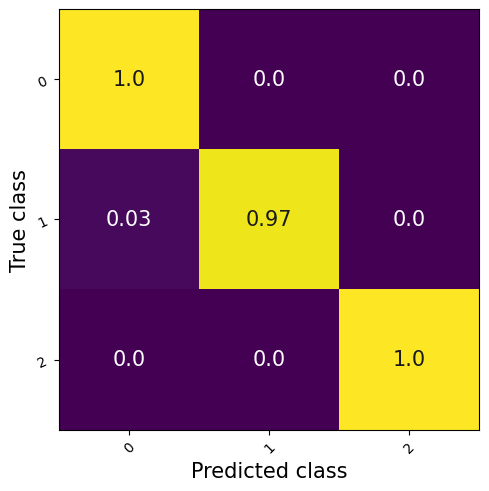

tensor([[12305,     3,     1],
        [    3,   115,     0],
        [    0,     0,   117]])
Macro F1-Score: 0.9900 ✨
perclass_f1scores: tensor([0.9997, 0.9746, 0.9957])
perclass_precision: tensor([0.9998, 0.9746, 0.9915])
perclass_recall: tensor([0.9997, 0.9746, 1.0000])
MAE overall: 1.4723 ✨
MAE per_class: {1: np.float64(1.2372881355932204), 2: np.float64(1.7094017094017093)} ✨
 === Currently Evaluating curr_test_idx: 8 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_10_T1/10_1_2mW_IPhone.xls
cropped_array shape: (51, 256, 7)
all_arrays shape: (51, 256, 7)
torch.Size([51, 256, 6])
Pred torch.Size([13056]) Target torch.Size([13056])


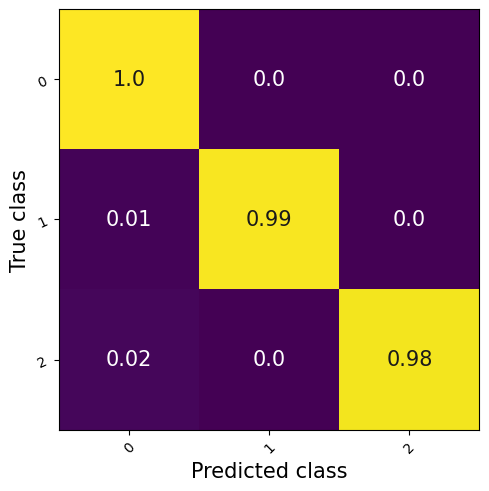

tensor([[12834,     5,     3],
        [    1,   106,     0],
        [    2,     0,   105]])
Macro F1-Score: 0.9829 ✨
perclass_f1scores: tensor([0.9996, 0.9725, 0.9767])
perclass_precision: tensor([0.9998, 0.9550, 0.9722])
perclass_recall: tensor([0.9994, 0.9907, 0.9813])
MAE overall: 1.1449 ✨
MAE per_class: {1: np.float64(1.1869158878504673), 2: np.float64(1.102803738317757)} ✨
 === Currently Evaluating curr_test_idx: 14 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_16_T1/16_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


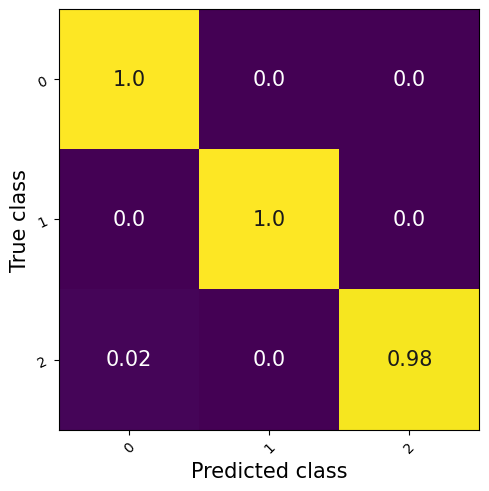

tensor([[12279,     1,     4],
        [    0,   130,     0],
        [    2,     0,   128]])
Macro F1-Score: 0.9910 ✨
perclass_f1scores: tensor([0.9997, 0.9962, 0.9771])
perclass_precision: tensor([0.9998, 0.9924, 0.9697])
perclass_recall: tensor([0.9996, 1.0000, 0.9846])
MAE overall: 1.0538 ✨
MAE per_class: {1: np.float64(0.6692307692307692), 2: np.float64(1.4384615384615385)} ✨
 === Currently Evaluating curr_test_idx: 21 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_24_T1/24_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


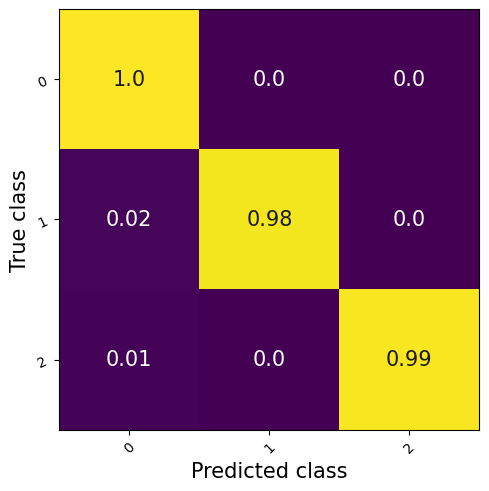

tensor([[12553,     3,     3],
        [    2,   119,     0],
        [    1,     0,   119]])
Macro F1-Score: 0.9875 ✨
perclass_f1scores: tensor([0.9996, 0.9794, 0.9835])
perclass_precision: tensor([0.9998, 0.9754, 0.9754])
perclass_recall: tensor([0.9995, 0.9835, 0.9917])
MAE overall: 0.7417 ✨
MAE per_class: {1: np.float64(0.6583333333333333), 2: np.float64(0.825)} ✨
 === Currently Evaluating curr_test_idx: 26 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_29_T1/29_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


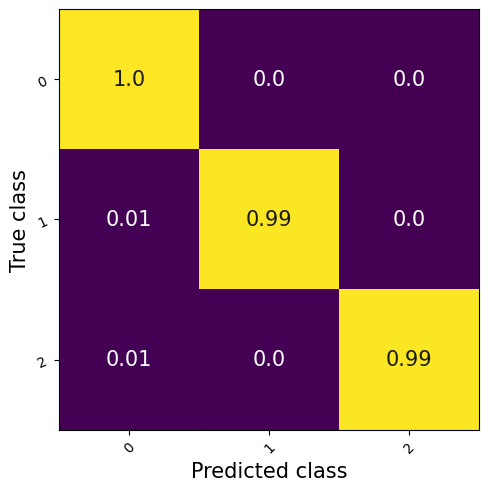

tensor([[12534,     2,     1],
        [    1,   131,     0],
        [    1,     0,   130]])
Macro F1-Score: 0.9936 ✨
perclass_f1scores: tensor([0.9998, 0.9887, 0.9924])
perclass_precision: tensor([0.9998, 0.9850, 0.9924])
perclass_recall: tensor([0.9998, 0.9924, 0.9924])
MAE overall: 0.7748 ✨
MAE per_class: {1: np.float64(0.9318181818181818), 2: np.float64(0.6153846153846154)} ✨
 === Currently Evaluating curr_test_idx: 29 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_32_T1/32_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


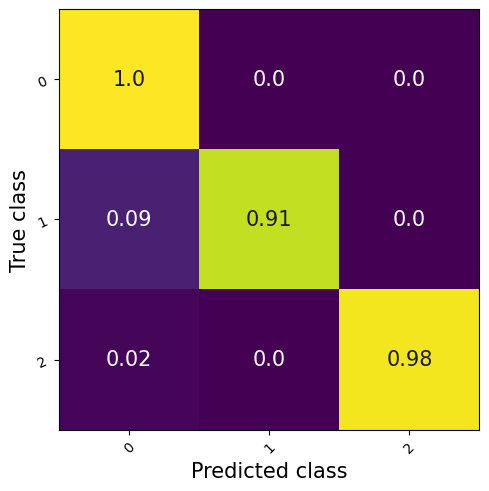

tensor([[12549,    11,     3],
        [   11,   108,     0],
        [    2,     0,   116]])
Macro F1-Score: 0.9618 ✨
perclass_f1scores: tensor([0.9989, 0.9076, 0.9789])
perclass_precision: tensor([0.9990, 0.9076, 0.9748])
perclass_recall: tensor([0.9989, 0.9076, 0.9831])
MAE overall: 1.4788 ✨
MAE per_class: {1: np.float64(2.0677966101694913), 2: np.float64(0.8898305084745762)} ✨
 === Currently Evaluating curr_test_idx: 31 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_34_T1/34_1_2mW_IPhone.xls
cropped_array shape: (49, 256, 7)
all_arrays shape: (49, 256, 7)
torch.Size([49, 256, 6])
Pred torch.Size([12544]) Target torch.Size([12544])


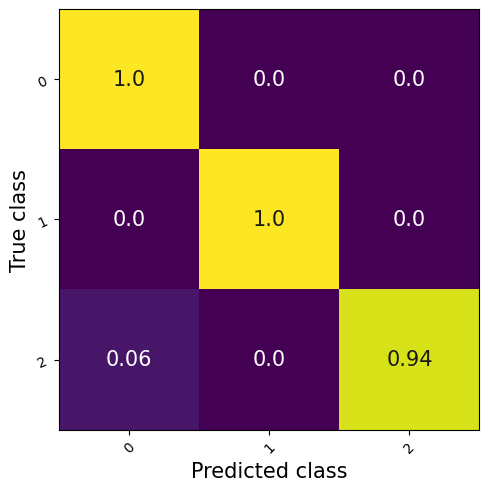

tensor([[12301,     1,     8],
        [    0,   117,     0],
        [    7,     0,   110]])
Macro F1-Score: 0.9771 ✨
perclass_f1scores: tensor([0.9994, 0.9957, 0.9362])
perclass_precision: tensor([0.9994, 0.9915, 0.9322])
perclass_recall: tensor([0.9993, 1.0000, 0.9402])
MAE overall: 0.8718 ✨
MAE per_class: {1: np.float64(0.7863247863247863), 2: np.float64(0.9572649572649573)} ✨
 === Currently Evaluating curr_test_idx: 37 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_40_T1/40_1_2mW_IPhone.xls
cropped_array shape: (52, 256, 7)
all_arrays shape: (52, 256, 7)
torch.Size([52, 256, 6])
Pred torch.Size([13312]) Target torch.Size([13312])


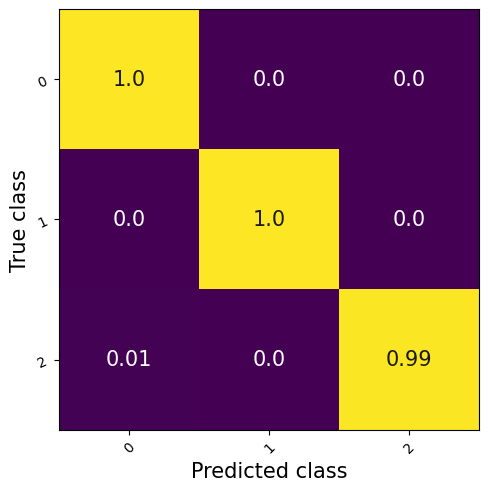

tensor([[13024,     0,     1],
        [    0,   144,     0],
        [    1,     0,   142]])
Macro F1-Score: 0.9976 ✨
perclass_f1scores: tensor([0.9999, 1.0000, 0.9930])
perclass_precision: tensor([0.9999, 1.0000, 0.9930])
perclass_recall: tensor([0.9999, 1.0000, 0.9930])
MAE overall: 0.9512 ✨
MAE per_class: {1: np.float64(0.5694444444444444), 2: np.float64(1.3356643356643356)} ✨
 === Currently Evaluating curr_test_idx: 44 === 
/home/geromevivar/projects/spine_interaction/data/dataset2/10092025/imu/Mobilephone/Termin_1_Vicon/ID_47_T1/47_1_2mW_IPhone.xls
cropped_array shape: (50, 256, 7)
all_arrays shape: (50, 256, 7)
torch.Size([50, 256, 6])
Pred torch.Size([12800]) Target torch.Size([12800])


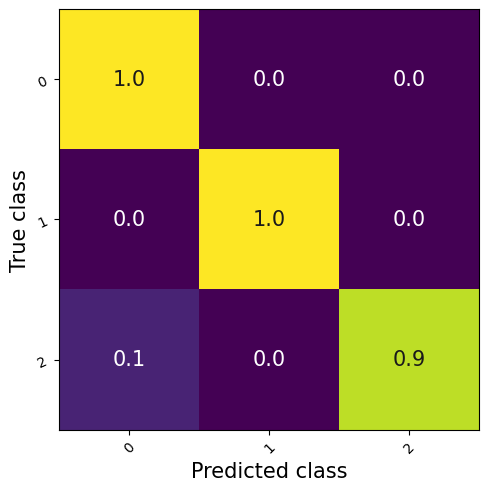

tensor([[12539,     1,    17],
        [    0,   122,     0],
        [   12,     0,   109]])
Macro F1-Score: 0.9591 ✨
perclass_f1scores: tensor([0.9988, 0.9959, 0.8826])
perclass_precision: tensor([0.9990, 0.9919, 0.8651])
perclass_recall: tensor([0.9986, 1.0000, 0.9008])
MAE overall: 1.1317 ✨
MAE per_class: {1: np.float64(1.3524590163934427), 2: np.float64(0.9090909090909091)} ✨


In [19]:
# Evaluate all best model on the validation set
num_folds = 5
exp_labels = [4]
data_set = "test"
for i in range(num_folds):
    for j in exp_labels:
        curr_model_path = np.sort(glob(f"/home/geromevivar/projects/gait_ml/backpain/Fold{i+1}*expandlabel{j}*/*/*"))[-1]
        save_name = f"Fold{i+1}_explabel{j}_{Path(curr_model_path).stem}.npz"
        if data_set == "test":
            save_name = f"{data_set}set_{save_name}"
        # if not os.path.exists(save_name):
        print(f"=== Running model: {save_name} ===")
        testset_results = eval(data_set=data_set, model_fpath=curr_model_path, fold=i)
        np.savez(save_name, **testset_results)

In [20]:
testset_all_results = []
testset_fnames = np.sort(glob("testset_Fold*"))
for fname in testset_fnames:
    print(f"Loading {fname}")
    curr_results = np.load(fname, allow_pickle=True)
    curr_results = {**curr_results}
    curr_results["fold"] = i + 1
    curr_results["explabel"] = j
    testset_all_results.append(curr_results)

Loading testset_Fold1_explabel4_model-epoch=52-val_f1score=0.91.npz
Loading testset_Fold2_explabel4_model-epoch=31-val_f1score=0.92.npz
Loading testset_Fold3_explabel4_model-epoch=27-val_f1score=0.91.npz
Loading testset_Fold4_explabel4_model-epoch=23-val_f1score=0.89.npz
Loading testset_Fold5_explabel4_model-epoch=47-val_f1score=0.91.npz


In [46]:
testset_all_results_df = pd.DataFrame(testset_all_results)
testset_all_results_df


,testset_f1_scores,testset_pc_f1_scores,testset_pc_precision,testset_pc_recall,testset_mae,testset_pc_mae,testset_cm,group,fold,explabel
0,"[0.99011433, 0.98008555, 0.99621487, 0.9921621...","[[0.9996741, 0.974359, 0.99630994], [0.9993207...","[[0.999837, 0.9637681, 0.99264705], [0.9992807...","[[0.9995112, 0.9851852, 1.0], [0.9993606, 0.95...","[1.548148148148148, 1.5473684210526315, 1.0861...","[{1: 1.651851851851852, 2: 1.4444444444444444}...","[[[12268, 5, 1], [2, 133, 0], [0, 0, 135]], [[...","[0, 0, 0, 0, 1, 1, 0, 1, 1, 1]",5,4
1,"[0.9723549, 0.9406434, 0.98841536, 0.98650265,...","[[0.99928766, 0.96581197, 0.9519651], [0.99804...","[[0.99962497, 0.94166666, 0.9396552], [0.99833...","[[0.9989506, 0.99122804, 0.96460176], [0.99775...","[1.1327433628318584, 1.3969465648854962, 0.988...","[{1: 0.5575221238938053, 2: 1.7079646017699115...","[[[13327, 7, 7], [1, 113, 0], [4, 0, 109]], [[...","[0, 0, 0, 1, 1, 1, 1, 0, 0]",5,4
2,"[0.99249274, 0.988732, 0.9836806, 0.9841308, 0...","[[0.9997556, 0.9851852, 0.9925373], [0.9996255...","[[1.0, 0.9708029, 0.9851852], [0.9997504, 0.97...","[[0.9995113, 1.0, 1.0], [0.9995008, 0.97761196...","[0.6353383458646616, 0.9253731343283582, 0.834...","[{1: 0.6616541353383458, 2: 0.6090225563909775...","[[[12272, 4, 2], [0, 133, 0], [0, 0, 133]], [[...","[0, 0, 0, 1, 1, 0, 0, 1, 1]",5,4
3,"[0.9914917, 0.9611516, 0.98230016, 0.98415434,...","[[0.9997562, 0.9831933, 0.9915254], [0.9986404...","[[0.99991876, 0.975, 0.9831933], [0.9988002, 0...","[[0.9995938, 0.9915254, 1.0], [0.99848074, 0.8...","[0.6851063829787234, 1.316326530612245, 1.2477...","[{1: 0.8898305084745762, 2: 0.4786324786324786...","[[[12304, 3, 2], [1, 117, 0], [0, 0, 117]], [[...","[0, 0, 0, 0, 0, 1, 1, 1, 1]",5,4
4,"[0.99001217, 0.982931, 0.9909943, 0.98751223, ...","[[0.9997156, 0.9745763, 0.9957447], [0.9995716...","[[0.9997563, 0.9745763, 0.9915254], [0.9997663...","[[0.99967504, 0.9745763, 1.0], [0.9993771, 0.9...","[1.4723404255319148, 1.144859813084112, 1.0538...","[{1: 1.2372881355932204, 2: 1.7094017094017093...","[[[12305, 3, 1], [3, 115, 0], [0, 0, 117]], [[...","[0, 0, 1, 0, 0, 1, 0, 1, 1]",5,4


In [25]:
testset_all_results_df.testset_mae.apply(lambda x:len(x))

0    10
1     9
2     9
3     9
4     9
Name: testset_mae, dtype: int64

In [26]:
cm_per_fold = testset_all_results_df.testset_cm.apply(lambda x: np.stack(x).sum(0)/np.stack(x).sum(0).sum(1))
cm_per_fold

0    [[0.9996676452667147, 0.01655379984951091, 0.0...
1    [[0.9992327501058276, 0.046431642304385214, 0....
2    [[0.999179553034762, 0.04952215464813206, 0.03...
3    [[0.999083597281042, 0.04965156794425087, 0.04...
4    [[0.9993981555236932, 0.024324324324324326, 0....
Name: testset_cm, dtype: object

In [27]:
combined_cm = testset_all_results_df.testset_cm.apply(lambda x: np.stack(x).sum(0)).sum(0)
normalized_cm = (combined_cm/combined_cm.sum(1)).round(2)

In [473]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
# ... other imports ...

def plot_confusion_matrix(cm, class_names, title, fmt, cbar_label, cmap=plt.cm.Blues, file_name='confusion_matrix.png'):
    # ... (function body as executed above) ...
    fig, ax = plt.subplots(figsize=(5, 5))
    
    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        linewidths=0.5,
        linecolor='black',
        cbar=False,
        # cbar_kws={'label': cbar_label, 'orientation': 'vertical', 'pad': 0.04, 'aspect': 30},
        annot_kws={"fontsize": 16, "fontweight": "bold"},
        ax=ax,
        square=True
    )
    
    ax.set_title(title, fontsize=12, fontweight='bold', pad=5)
    ax.set_ylabel('True Label', fontsize=20, fontweight='medium')
    ax.set_xlabel('Predicted Label', fontsize=20, fontweight='medium')

    # Set class labels on ticks, centering them
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks + 0.5)
    ax.set_yticks(tick_marks + 0.5)
    ax.set_xticklabels(class_names, fontsize=16)
    ax.set_yticklabels(class_names, fontsize=16, rotation=90, va="center") 

    # Fix for half-pixel issues in matplotlib 3.1.1+ (sets the limits correctly)
    ax.set_ylim(len(class_names), 0)
    ax.tick_params(axis='both', which='major', length=0) 

    plt.tight_layout()
    
    # ... (code to set ticks and save figure) ...
    # plt.savefig(file_name, dpi=300, bbox_inches='tight')
    # fig.show()
    # plt.close(fig)
    return fig

0
1
2
3
4


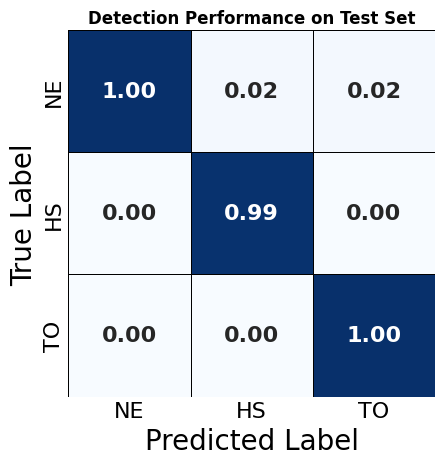

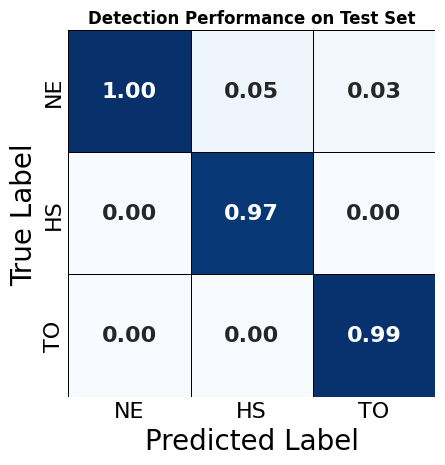

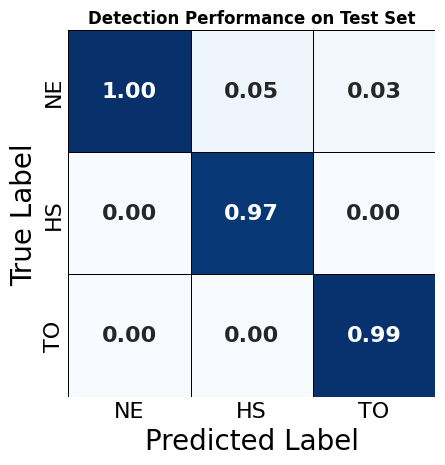

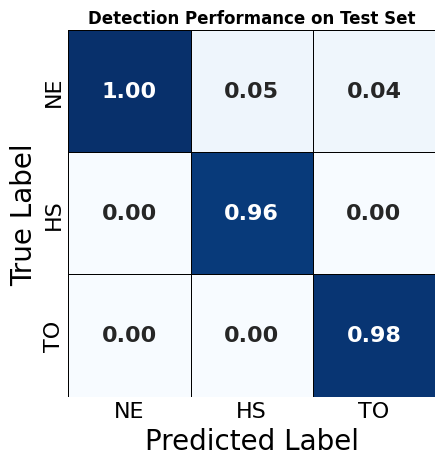

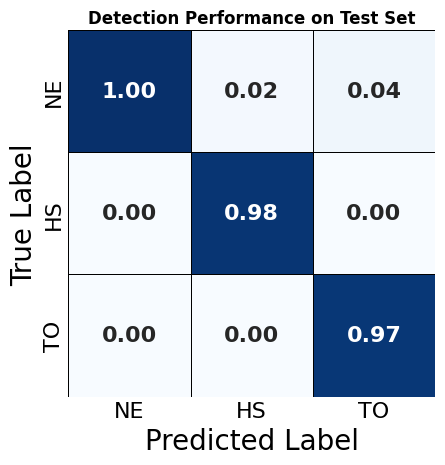

In [474]:
for k, v in testset_all_results_df.iterrows():
    print(k)
    plot_confusion_matrix((np.stack(v.testset_cm).sum(0)/np.stack(v.testset_cm).sum(0).sum(1)).round(2), ["NE", "HS", "TO"], "Detection Performance on Test Set", ".2f", ["NE", "HS", "TO"])

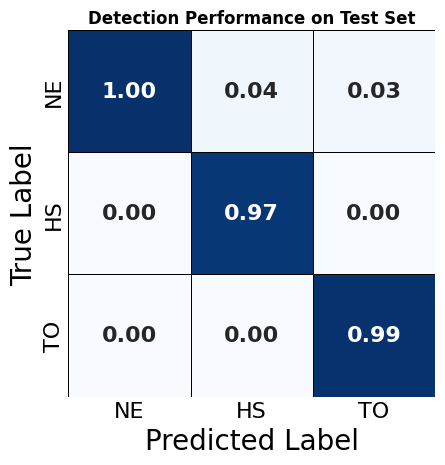

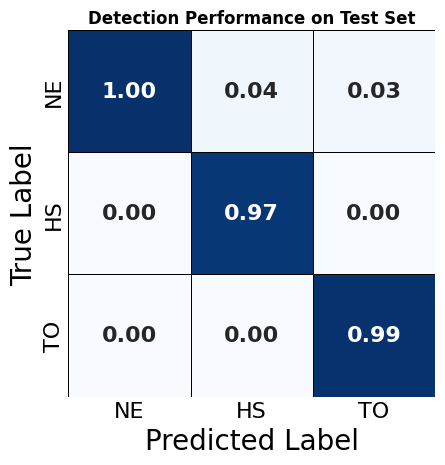

In [475]:
plot_confusion_matrix(normalized_cm, ["NE", "HS", "TO"], "Detection Performance on Test Set", ".2f", ["NE", "HS", "TO"])

## 2.3 Table detection and MAE metrics on test set mean [std]
- F1-score, Precision, Recall, TP, FP, FN, MAE per class per group

In [380]:
metrics_per_fold = []
for k,v in testset_all_results_df.iterrows():
    print(f"==Processing fold: {k}==")
    for j in range(2):
        print(f"Group: {j}")
        curr_metrics = dict()
        curr_group = v.group
        curr_metrics["f1-score"] = v.testset_pc_f1_scores[curr_group == j].mean(0)
        curr_metrics["recall"] = v.testset_pc_recall[curr_group == j].mean(0)
        curr_metrics["precision"] = v.testset_pc_precision[curr_group == j].mean(0)
        curr_mae = pd.Series(v.testset_pc_mae[curr_group == j]).apply(lambda x: [x[idx+1] for idx in range(2)])
        curr_mae = np.stack(curr_mae).mean(0)
        curr_mae = np.hstack([np.array([np.nan]), curr_mae])
        curr_metrics["mae"] = curr_mae
        curr_metrics["group"] = j
        curr_metrics["fold"] = k+1        
        metrics_per_fold.append(curr_metrics)

results_df = pd.DataFrame(metrics_per_fold)
# results_df.drop(columns=["fold"], inplace=True)

==Processing fold: 0==
Group: 0
Group: 1
==Processing fold: 1==
Group: 0
Group: 1
==Processing fold: 2==
Group: 0
Group: 1
==Processing fold: 3==
Group: 0
Group: 1
==Processing fold: 4==
Group: 0
Group: 1


In [442]:
# Prepare dataframe for plotting
plot_df = results_df.melt(["group", "fold"])
event_df = pd.DataFrame(plot_df['value'].apply(pd.Series))
event_df.columns = ["NE", "HS", "TO"]
plot_df.drop(columns="value", inplace=True)
plot_df = pd.concat([plot_df, event_df], axis=1)

df_long = plot_df.melt(id_vars=['group', 'fold', 'variable'], 
                  value_vars=['NE', 'HS', 'TO'],
                  var_name='event', # New column for the variable names
                  value_name='value')

df_long.group.replace(0, "Healthy", inplace=True)
df_long.group.replace(1, "BackPain", inplace=True)
df_long.variable.replace("mae", "MAE", inplace=True)
df_long.rename(columns={"variable":"Metric", "group": "Group"}, inplace=True)

/tmp/ipykernel_956315/3434757740.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_long.group.replace(0, "Healthy", inplace=True)
/tmp/ipykernel_956315/3434757740.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)

<Figure size 1000x500 with 0 Axes>

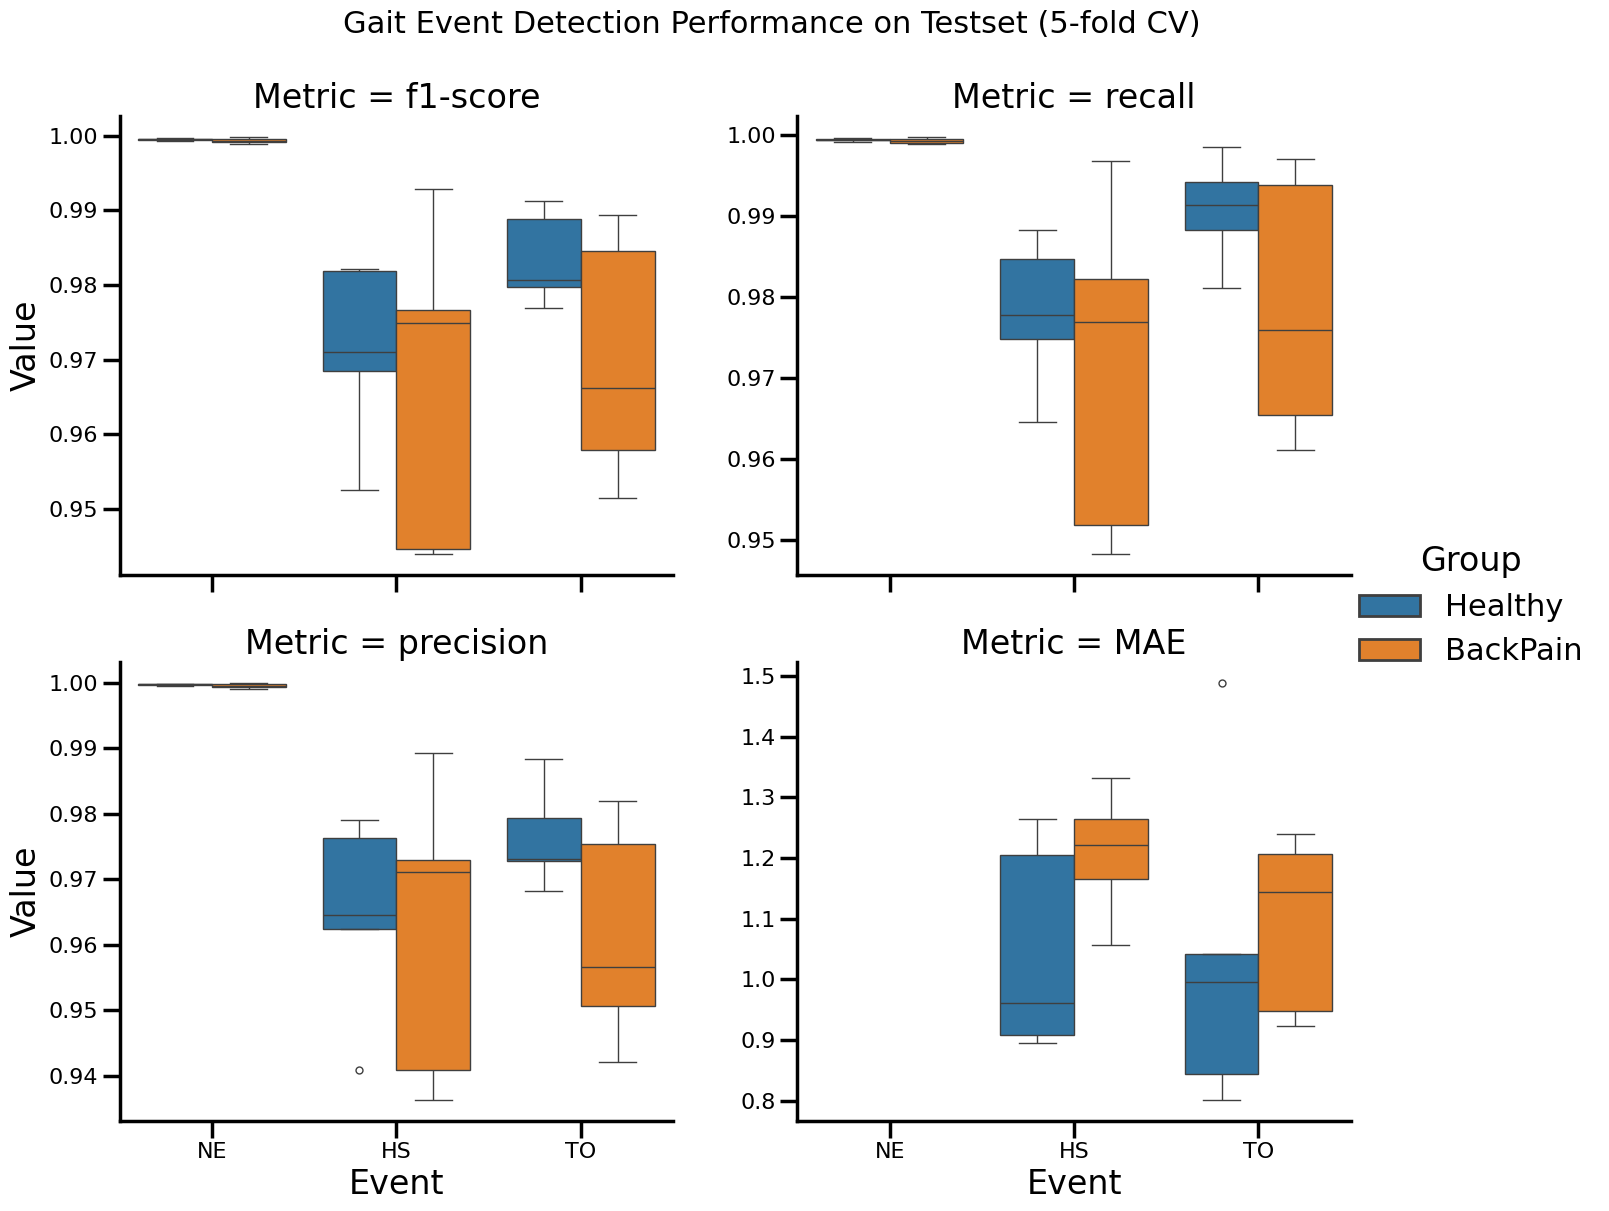

In [477]:
plt.figure(figsize=(10, 5))
sns.set_context("poster")
g = sns.catplot(data=df_long, 
                x="event", 
                y="value", 
                hue="Group", 
                kind="box", 
                col='Metric',
                col_wrap=2,
                height=6, 
                aspect=1.2, sharey=False)
# Add a main title to the figure
g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=22)

# Improve axis labels|
g.tick_params(axis='both', which='major', labelsize=16)
# plt.tight_layout(rect=[0, 0, 1, 0.97])
g.set_axis_labels("Event", "Value")

plt.show()

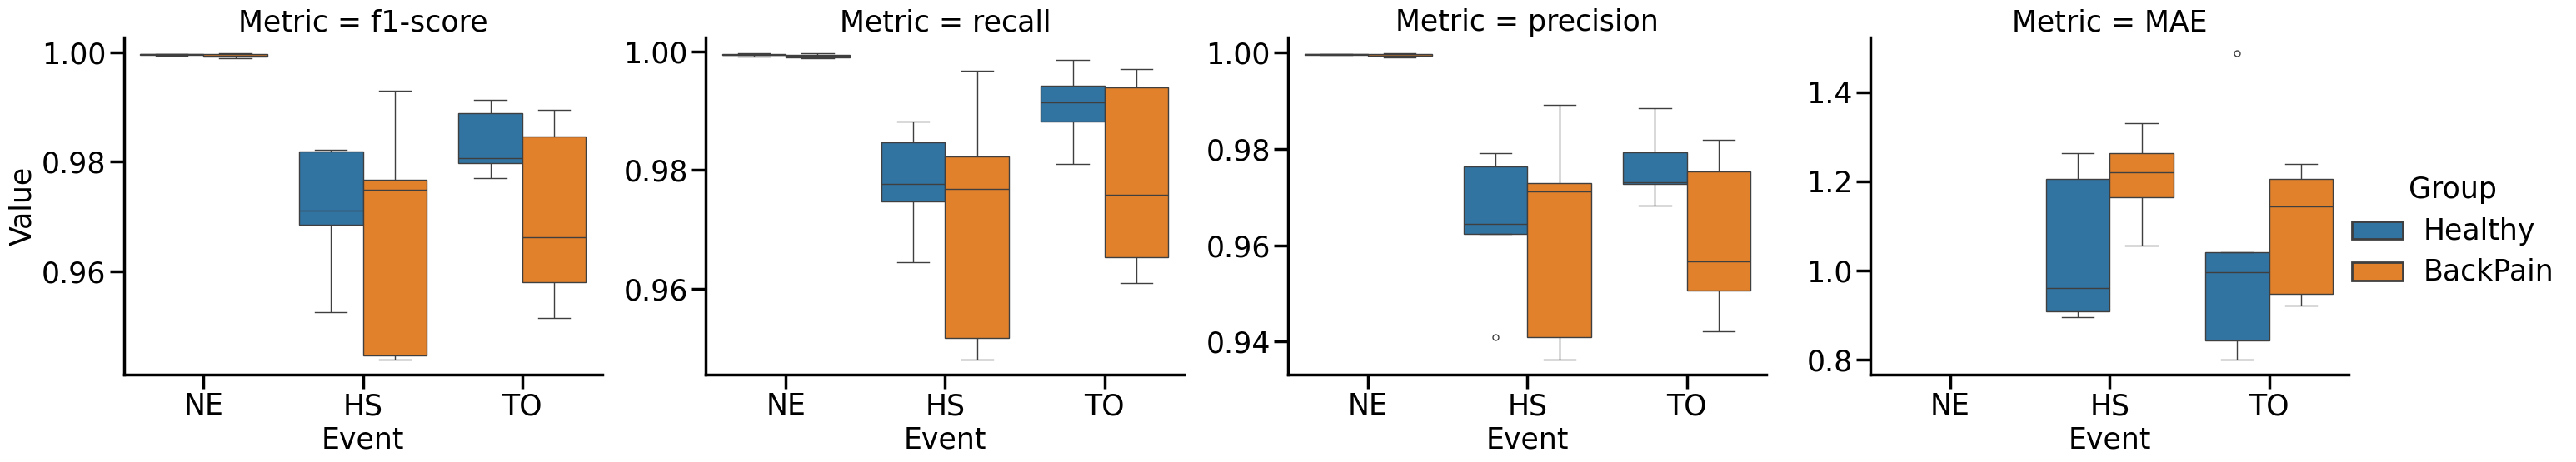

In [493]:
# Create the plot
g = sns.catplot(data=df_long,
                x="event",
                y="value",
                hue="Group",
                kind="box",
                col='Metric',
                # col_wrap=2,
                height=6,
                aspect=1.2,
                sharey=False,
                legend_out=True)

# 1. Main Title
# g.fig.suptitle('Gait Event Detection Performance on Testset (5-fold CV)', y=1.03, fontsize=20)

# 2. Subplot Titles (e.g., "Metric = Accuracy")
g.set_titles(size=25)

# 3. Axis Labels
g.set_axis_labels("Event", "Value", fontsize=25)

# 4. Tick Labels
g.tick_params(axis='both', which='major', labelsize=25)

# 5. Legend Title and Labels
if g.legend:
    plt.setp(g.legend.get_texts(), fontsize='25')
    plt.setp(g.legend.get_title(), fontsize='25')

# Adjust layout
# plt.tight_layout(rect=[0, 0, 1, 0.97])

plt.show()